# LOGISTIC REGRESSION MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [1]:
# -- Standard library ----------------------------------------------------------
from pathlib import Path
from itertools import product

# -- Numerical / data ----------------------------------------------------------
import numpy as np
import pandas as pd

# -- Sklearn: preprocessing ----------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression

# -- Sklearn: model ------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# -- Sklearn: evaluation metrics -----------------------------------------------
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)

# -- Visualisation -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### PATHS

In [2]:
# -- Project root --------------------------------------------------------------
PROJECT_ROOT = Path('/Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval')

# -- Input data splits ---------------------------------------------------------
DATA_DIR      = PROJECT_ROOT / 'data'
TRAIN_PATH    = DATA_DIR / 'train.csv'
VALIDATE_PATH = DATA_DIR / 'validate.csv'
TEST_PATH     = DATA_DIR / 'test.csv'

# -- Output directory ----------------------------------------------------------
LOGREG_OUTPUT_DIR = PROJECT_ROOT / 'output' / 'logreg'
LOGREG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -- Unconstrained model outputs -----------------------------------------------
UNC_BASELINE_CSV        = LOGREG_OUTPUT_DIR / 'logreg_unconstrained_baseline_validation_results.csv'
UNC_TUNING_CSV          = LOGREG_OUTPUT_DIR / 'logreg_unconstrained_tuning_results_validation.csv'
UNC_VALIDATION_CMP_CSV  = LOGREG_OUTPUT_DIR / 'logreg_unconstrained_validation_comparison.csv'
UNC_SELECTED_CSV        = LOGREG_OUTPUT_DIR / 'logreg_unconstrained_selected_model_validation.csv'

# -- Constrained model outputs -------------------------------------------------
CON_FIXED_CSV            = LOGREG_OUTPUT_DIR / 'logreg_constrained_fixed_selected_model_validation.csv'
CON_RETUNED_TUNING_CSV   = LOGREG_OUTPUT_DIR / 'logreg_constrained_retuned_tuning_results_validation.csv'
CON_RETUNED_SELECTED_CSV = LOGREG_OUTPUT_DIR / 'logreg_constrained_retuned_selected_model_validation.csv'
CON_VALIDATION_CMP_CSV   = LOGREG_OUTPUT_DIR / 'logreg_constrained_validation_comparison.csv'

# -- Final cross-model comparison ----------------------------------------------
FINAL_COMPARISON_CSV = LOGREG_OUTPUT_DIR / 'logreg_final_comparison.csv'

# -- Shared constants ----------------------------------------------------------
RANDOM_STATE = 42                              # Global seed for reproducibility
SOLVER_MAP   = {'l1': 'saga', 'l2': 'lbfgs'}  # saga required for L1; lbfgs preferred for L2

### DATA VALIDATION

In [3]:
train_df    = pd.read_csv(TRAIN_PATH,    low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df     = pd.read_csv(TEST_PATH,     low_memory=False)

print("Shapes:")
print(f"  train:    {train_df.shape}")
print(f"  validate: {validate_df.shape}")
print(f"  test:     {test_df.shape}")
print("\nColumn match:")
print("  train / validate:", list(train_df.columns) == list(validate_df.columns))
print("  train / test:    ", list(train_df.columns) == list(test_df.columns))

Shapes:
  train:    (215137, 33)
  validate: (46101, 33)
  test:     (46101, 33)

Column match:
  train / validate: True
  train / test:     True


In [4]:
TARGET_COLUMN = "TARGET"
ID_COLUMN     = "SK_ID_CURR"

print("Default rate by split:")
print("  Train:   ", train_df[TARGET_COLUMN].mean())
print("  Validate:", validate_df[TARGET_COLUMN].mean())
print("  Test:    ", test_df[TARGET_COLUMN].mean())

dtype_to_columns = (
    train_df.dtypes
    .astype(str)
    .groupby(train_df.dtypes.astype(str))
    .apply(lambda s: sorted(s.index.tolist()))
)
print("\nFeatures by dtype:")
for dtype_name, columns in dtype_to_columns.items():
    print(f"  {dtype_name}: {columns}")

Default rate by split:
  Train:    0.08072995347150885
  Validate: 0.08073577579662046
  Test:     0.08071408429318236

Features by dtype:
  float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
  int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'SK_ID_CURR', 'TARGET']
  object: ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


### NOTE — Missing Value Handling in Logistic Regression

Unlike XGBoost, logistic regression cannot handle `NaN` values natively —
all features must be fully numeric before training.

**Strategy applied here:**
- **Numeric columns** — imputed with the training-set median  
  (imputer fitted on `train` only, then applied to `validate` / `test` to prevent leakage)
- **Categorical columns** — already carry a `'MISSING'` placeholder string from upstream  
  preprocessing, so they are handled naturally by one-hot encoding

### PREP DATA FOR MODEL TRAINING

##### Separate labels

In [5]:
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val   = validate_df[TARGET_COLUMN].astype(int).copy()
y_test  = test_df[TARGET_COLUMN].astype(int).copy()

X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val   = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test  = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

print(f"X_train | shape: {X_train.shape}  | type: {type(X_train)}")
print(f"X_val   | shape: {X_val.shape}    | type: {type(X_val)}")
print(f"X_test  | shape: {X_test.shape}   | type: {type(X_test)}")
print()
print(f"y_train | shape: {y_train.shape}  | type: {type(y_train)}")
print(f"y_val   | shape: {y_val.shape}    | type: {type(y_val)}")
print(f"y_test  | shape: {y_test.shape}   | type: {type(y_test)}")

X_train | shape: (215137, 31)  | type: <class 'pandas.core.frame.DataFrame'>
X_val   | shape: (46101, 31)    | type: <class 'pandas.core.frame.DataFrame'>
X_test  | shape: (46101, 31)   | type: <class 'pandas.core.frame.DataFrame'>

y_train | shape: (215137,)  | type: <class 'pandas.core.series.Series'>
y_val   | shape: (46101,)    | type: <class 'pandas.core.series.Series'>
y_test  | shape: (46101,)   | type: <class 'pandas.core.series.Series'>


##### Identify column types

In [6]:
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns     = [col for col in X_train.columns if col not in categorical_columns]

print(f"# numeric columns:     {len(numeric_columns)}")
print(f"# categorical columns: {len(categorical_columns)}")
print("\nNumeric:",     numeric_columns)
print("\nCategorical:", categorical_columns)

# numeric columns:     23
# categorical columns: 8

Numeric: ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']

Categorical: ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


## EVALUATION METRICS

(Same for constrained and unconstrained models)

### Kolmogorov-Smirnov (KS) Stat

Very common in credit scoring. Measures the point where the model does the best job of
separating defaulters from good borrowers.

In [7]:
def compute_ks(y_true, y_score):
    """
    Compute the Kolmogorov-Smirnov statistic for a binary classifier.

    Sorts observations from highest to lowest predicted risk, then builds
    cumulative default-rate and non-default-rate curves. The KS statistic
    is the maximum absolute gap between those two curves.

    Returns float in [0,1]; np.nan if one class is absent.
    """
    # Align inputs and sort highest predicted risk first
    df_ks = pd.DataFrame({
        'y_true':  pd.Series(y_true).reset_index(drop=True),
        'y_score': pd.Series(y_score).reset_index(drop=True),
    }).sort_values('y_score', ascending=False).reset_index(drop=True)

    total_pos = (df_ks['y_true'] == 1).sum()   # Total actual defaults
    total_neg = (df_ks['y_true'] == 0).sum()   # Total actual non-defaults

    # Defensive: return NaN if a class is completely absent
    if total_pos == 0 or total_neg == 0:
        return np.nan

    # Cumulative share of defaults and non-defaults captured at each rank
    df_ks['cum_pos'] = (df_ks['y_true'] == 1).cumsum() / total_pos
    df_ks['cum_neg'] = (df_ks['y_true'] == 0).cumsum() / total_neg

    # KS = maximum vertical distance between the two cumulative curves
    return float(np.max(np.abs(df_ks['cum_pos'] - df_ks['cum_neg'])))

### Eval Helpers

##### Compute metrics

Helper func to evaluate fitted model with metrics:
- **PR-AUC** *(primary)* — tradeoff between precision and recall (esp. important given class imbalance)
- **ROC-AUC** — how well model ranks true defaulters over non-defaulters across classification thresholds
- **Brier Score** — how close predicted default probabilities are to actual outcomes
- **KS Statistic** — maximum separation between cumulative distributions of defaulters and non-defaulters when ranked by predicted risk

*PR-AUC is the primary metric by which candidate models are selected during hyperparameter tuning*
*because of the large class imbalance in defaulters vs non-defaulters*

In [8]:
def evaluate_binary_model(model, X, y, split_name, model_name):
    """
    Evaluate a fitted binary classifier and return a metrics dictionary.

    Metrics: pr_auc (primary), roc_auc, brier_score, ks_stat
    """
    # Predicted probability of the positive class (default = 1)
    y_proba = model.predict_proba(X)[:, 1]

    # Compute each metric individually for clarity and easier debugging
    pr_auc      = average_precision_score(y, y_proba)   # Primary: robust to class imbalance
    roc_auc     = roc_auc_score(y, y_proba)
    brier_score = brier_score_loss(y, y_proba)          # Lower is better
    ks_stat     = compute_ks(y, y_proba)

    return {
        'model_name':  model_name,
        'split':       split_name,
        'pr_auc':      pr_auc,
        'roc_auc':     roc_auc,
        'brier_score': brier_score,
        'ks_stat':     ks_stat,
    }

##### Plots

In [9]:
# -- ROC curve ----------------------------------------------------------------
def plot_roc_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value   = roc_auc_score(y_true, y_proba)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_value:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='grey')  # Random baseline
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# -- Precision-Recall curve ---------------------------------------------------
def plot_pr_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc_value = average_precision_score(y_true, y_proba)
        plt.plot(recall, precision, label=f'{label} (PR-AUC = {pr_auc_value:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# -- Bar chart: multi-model metric comparison ---------------------------------
def plot_metric_comparison(results_df, split_name, metric_name, title):
    plot_df = results_df[results_df['split'] == split_name].copy()
    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x='model_name', y=metric_name)
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


# -- Dot-plot: two-model comparison (makes small gaps clearly visible) --------
def plot_two_model_comparison(
    compare_df,
    value_col,
    title,
    x_label=None,
    as_percent=False,
    decimals=4,
):
    """
    Horizontal dot-plot comparing models on a single metric.
    Tight x-axis range makes even small differences clearly visible.
    """
    plot_df     = compare_df[['model_name', value_col]].copy()
    raw_values  = plot_df[value_col].astype(float).to_numpy()
    disp_values = raw_values * 100 if as_percent else raw_values
    model_names = plot_df['model_name'].tolist()
    y_pos       = np.arange(len(plot_df))

    x_min   = disp_values.min()
    x_max   = disp_values.max()
    x_span  = x_max - x_min
    padding = max(x_span * 0.35, 0.001 if not as_percent else 0.05)

    plt.figure(figsize=(8, 2.8))
    plt.plot(disp_values, y_pos, linewidth=1, alpha=0.7, color='steelblue')
    plt.scatter(disp_values, y_pos, s=80, color='steelblue', zorder=3)

    for x, y in zip(disp_values, y_pos):
        label = f"{x:.{decimals}f}{'%' if as_percent else ''}"
        plt.text(x + padding * 0.05, y, label, va='center', fontsize=9)

    plt.yticks(y_pos, model_names)
    plt.xlim(x_min - padding, x_max + padding)
    plt.xlabel(x_label if x_label is not None else value_col)
    plt.title(title)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## UNCONSTRAINED LOGISTIC REGRESSION MODEL

### Preprocessing — Unconstrained

1. Impute missing numeric values with training-set median
2. StandardScaler on numeric features
3. One-hot encode categorical features via `pd.get_dummies`


In [10]:
# Fit imputer on training data only — prevents leakage into val/test
unc_imputer = SimpleImputer(strategy='median')  # Median is robust to outliers
unc_scaler  = StandardScaler()                  # Z-score normalisation required by logistic regression

# Working copies — never mutate the raw DataFrames
X_train_unc = X_train.copy()
X_val_unc   = X_val.copy()
X_test_unc  = X_test.copy()

# -- Imputation: fit on train only, transform val/test without refitting ------
X_train_unc[numeric_columns] = unc_imputer.fit_transform(X_train[numeric_columns])
X_val_unc[numeric_columns]   = unc_imputer.transform(X_val[numeric_columns])
X_test_unc[numeric_columns]  = unc_imputer.transform(X_test[numeric_columns])

# -- Scaling ------------------------------------------------------------------
X_train_unc[numeric_columns] = unc_scaler.fit_transform(X_train_unc[numeric_columns])
X_val_unc[numeric_columns]   = unc_scaler.transform(X_val_unc[numeric_columns])
X_test_unc[numeric_columns]  = unc_scaler.transform(X_test_unc[numeric_columns])

assert X_train_unc[numeric_columns].isna().sum().sum() == 0
print('Imputation complete - no remaining nulls in numeric columns')

Imputation complete - no remaining nulls in numeric columns


In [11]:
# One-hot encode categorical features (drop_first=False retains all levels for inspection)
X_train_unc = pd.get_dummies(X_train_unc, columns=categorical_columns, drop_first=False, dtype=int)
X_val_unc   = pd.get_dummies(X_val_unc,   columns=categorical_columns, drop_first=False, dtype=int)
X_test_unc  = pd.get_dummies(X_test_unc,  columns=categorical_columns, drop_first=False, dtype=int)

# Align val/test to training schema — unseen levels filled with 0
X_val_unc  = X_val_unc.reindex(columns=X_train_unc.columns, fill_value=0)
X_test_unc = X_test_unc.reindex(columns=X_train_unc.columns, fill_value=0)

print('Train/validate columns match:', list(X_train_unc.columns) == list(X_val_unc.columns))
print('Train/test columns match:    ', list(X_train_unc.columns) == list(X_test_unc.columns))
print(f'\nFinal unconstrained shapes:')
print(f'  X_train_unc: {X_train_unc.shape}')
print(f'  X_val_unc:   {X_val_unc.shape}')
print(f'  X_test_unc:  {X_test_unc.shape}')
print(f'\nColumn order stored - used for constrained feature alignment check')

Train/validate columns match: True
Train/test columns match:     True

Final unconstrained shapes:
  X_train_unc: (215137, 129)
  X_val_unc:   (46101, 129)
  X_test_unc:  (46101, 129)

Column order stored - used for constrained feature alignment check


### First Training Run (No Hyperparameter Tuning)

In [12]:
# -- Baseline logistic regression (default hyperparameters) ------------------
logreg_baseline = LogisticRegression(
    penalty='l2',            # L2 (Ridge) regularisation - shrinks all coefficients
    C=1.0,                   # Inverse regularisation strength; C=1.0 is sklearn default
    solver='lbfgs',          # Limited-memory BFGS - efficient and reliable for L2
    class_weight='balanced', # Upweights minority class (defaults) to correct class imbalance
    max_iter=1000,           # Generous iteration budget to ensure convergence
    random_state=RANDOM_STATE,
    n_jobs=-1,               # Use all available CPU cores
)
logreg_baseline.fit(X_train_unc, y_train)

# -- Convergence check --------------------------------------------------------
if hasattr(logreg_baseline, 'n_iter_'):
    converged = all(n < logreg_baseline.max_iter for n in logreg_baseline.n_iter_)
    print(f'Converged: {converged} | Iterations used: {logreg_baseline.n_iter_}')

# -- Evaluate on validation split ---------------------------------------------
baseline_val_prob   = logreg_baseline.predict_proba(X_val_unc)[:, 1]
baseline_val_result = evaluate_binary_model(
    model=logreg_baseline, X=X_val_unc, y=y_val,
    split_name='validation', model_name='logreg_unconstrained_baseline',
)

pd.DataFrame([baseline_val_result]).to_csv(UNC_BASELINE_CSV, index=False)
print(f'\nBaseline validation results:')
print(f"  PR-AUC (primary): {baseline_val_result['pr_auc']:.6f}")
print(f"  ROC-AUC:          {baseline_val_result['roc_auc']:.6f}")
print(f"  KS Stat:          {baseline_val_result['ks_stat']:.6f}")
print(f"  Brier Score:      {baseline_val_result['brier_score']:.6f}")
print(f'\nSaved: {UNC_BASELINE_CSV}')

Converged: True | Iterations used: [132]

Baseline validation results:
  PR-AUC (primary): 0.205673
  ROC-AUC:          0.739436
  KS Stat:          0.359193
  Brier Score:      0.206016

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_baseline_validation_results.csv


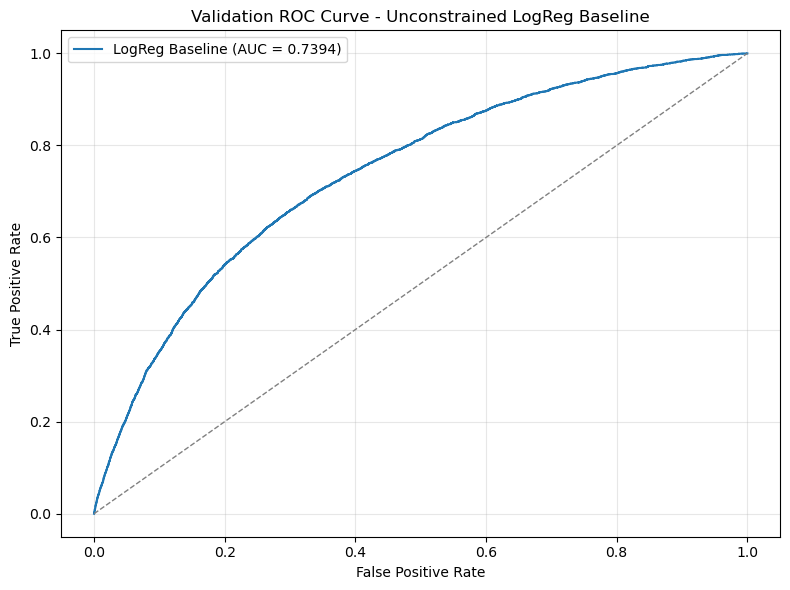

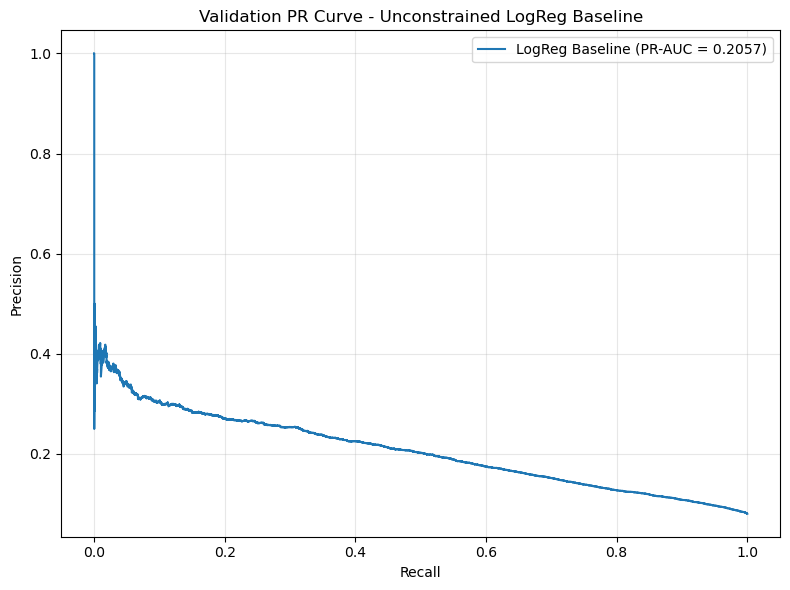

In [13]:
plot_roc_curves(
    curves_dict={"LogReg Baseline": (y_val, baseline_val_prob)},
    title="Validation ROC Curve - Unconstrained LogReg Baseline",
)
plot_pr_curves(
    curves_dict={"LogReg Baseline": (y_val, baseline_val_prob)},
    title="Validation PR Curve - Unconstrained LogReg Baseline",
)

### Hyperparameter Tuning

Grid search over candidate combinations evaluated on the **validate** split only.  
**PR-AUC is the primary selection metric** (preferred over ROC-AUC given class imbalance).

#### Search space and rationale

| Parameter | Values | Why included |
|---|---|---|
| `C` | 0.01, 0.1, 1.0, 10.0, 100.0 | Controls regularisation strength on a log scale — covers heavily to lightly regularised regimes |
| `penalty` | L1, L2 | L1 (saga solver) induces sparsity. L2 (lbfgs) shrinks all coefficients uniformly. Both are standard in credit scorecard practice |
| `class_weight` | `balanced`, `None` | Tests whether minority-class upweighting helps given the large default imbalance |

Total combinations: 5 x 2 x 2 = **20 candidates**

In [14]:
def train_and_evaluate_candidate(candidate_params, candidate_name, X_train_r, X_val_r):
    """
    Train one logistic regression candidate and evaluate it on the validation split.

    Works for both unconstrained and constrained preprocessing -
    caller passes the appropriate X matrices.

    Returns fitted_model, validation_result_dict
    """
    fitted_model = LogisticRegression(
        solver=SOLVER_MAP[candidate_params['penalty']],  # saga for L1, lbfgs for L2
        max_iter=300,   # Reduced for grid search speed; full fit uses 1000
        tol=1e-3,       # Looser tolerance speeds up saga with minimal quality loss
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **candidate_params,  # Unpacks C, penalty, class_weight
    )
    fitted_model.fit(X_train_r, y_train)

    # Evaluate on validation split
    validation_result = evaluate_binary_model(
        model=fitted_model, X=X_val_r, y=y_val,
        split_name='validation', model_name=candidate_name,
    )

    # Attach hyperparameter values to result row for traceability
    for param_name, param_value in candidate_params.items():
        validation_result[param_name] = param_value

    return fitted_model, validation_result

In [15]:
# itertools.product already imported at top of notebook

In [16]:
logreg_search_grid = {
    "C":            [0.01, 0.1, 1.0, 10.0, 100.0],
    "penalty":      ["l1", "l2"],
    "class_weight": ["balanced", None],
}

search_param_names  = list(logreg_search_grid.keys())
search_combinations = list(product(*logreg_search_grid.values()))
print(f"Number of candidate combinations: {len(search_combinations)}")

Number of candidate combinations: 20


In [17]:
unc_search_results = []
unc_search_models  = {}

for i, combo in enumerate(search_combinations, start=1):
    candidate_params = dict(zip(search_param_names, combo))
    candidate_name   = f"logreg_unc_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name,
        X_train_r=X_train_unc,
        X_val_r=X_val_unc,
    )
    unc_search_models[candidate_name] = fitted_model
    unc_search_results.append(validation_result)

unc_search_df = pd.DataFrame(unc_search_results).sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

unc_search_df.to_csv(UNC_TUNING_CSV, index=False)
print(f"Saved: {UNC_TUNING_CSV}")
unc_search_df.head(10)

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_tuning_results_validation.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat,C,penalty,class_weight
0,logreg_unc_candidate_18,validation,0.209218,0.738050,0.069281,0.361685,100.00,l1,None
1,logreg_unc_candidate_14,validation,0.209215,0.738048,0.069281,0.361709,10.00,l1,None
2,logreg_unc_candidate_10,validation,0.209193,0.738030,0.069282,0.361950,1.00,l1,None
3,logreg_unc_candidate_6,validation,0.208924,0.737842,0.069293,0.361185,0.10,l1,None
4,logreg_unc_candidate_20,validation,0.207647,0.736590,0.069359,0.356889,100.00,l2,None
5,logreg_unc_candidate_16,validation,0.207646,0.736589,0.069359,0.356889,10.00,l2,None
6,logreg_unc_candidate_12,validation,0.207643,0.736590,0.069359,0.356937,1.00,l2,None
7,logreg_unc_candidate_8,validation,0.207618,0.736594,0.069360,0.356997,0.10,l2,None
8,logreg_unc_candidate_4,validation,0.207386,0.736603,0.069363,0.357868,0.01,l2,None
9,logreg_unc_candidate_19,validation,0.206101,0.740150,0.206033,0.362599,100.00,l2,balanced


In [18]:
best_unc_name    = unc_search_df.loc[0, "model_name"]
best_logreg_unc  = unc_search_models[best_unc_name]

print("Selected tuned unconstrained logistic regression model:")
print(f"  Candidate name:     {best_unc_name}")
print(f"  C:                  {unc_search_df.loc[0, 'C']}")
print(f"  Penalty:            {unc_search_df.loc[0, 'penalty']}")
print(f"  Class weight:       {unc_search_df.loc[0, 'class_weight']}")
print(f"  Validation PR-AUC:  {unc_search_df.loc[0, 'pr_auc']:.6f}")
print(f"  Validation ROC-AUC: {unc_search_df.loc[0, 'roc_auc']:.6f}")
print(f"  Validation KS:      {unc_search_df.loc[0, 'ks_stat']:.6f}")
print(f"  Validation Brier:   {unc_search_df.loc[0, 'brier_score']:.6f}")

unc_search_df.head(1).to_csv(UNC_SELECTED_CSV, index=False)
print(f"\nSaved: {UNC_SELECTED_CSV}")

Selected tuned unconstrained logistic regression model:
  Candidate name:     logreg_unc_candidate_18
  C:                  100.0
  Penalty:            l1
  Class weight:       None
  Validation PR-AUC:  0.209218
  Validation ROC-AUC: 0.738050
  Validation KS:      0.361685
  Validation Brier:   0.069281

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_selected_model_validation.csv


In [19]:
tuned_unc_val_result = evaluate_binary_model(
    model=best_logreg_unc, X=X_val_unc, y=y_val,
    split_name="validation", model_name="logreg_unconstrained_tuned",
)
tuned_unc_val_prob = best_logreg_unc.predict_proba(X_val_unc)[:, 1]

unc_validation_compare_df = pd.DataFrame([baseline_val_result, tuned_unc_val_result])
unc_validation_compare_df.to_csv(UNC_VALIDATION_CMP_CSV, index=False)
print(f"Saved: {UNC_VALIDATION_CMP_CSV}")
unc_validation_compare_df

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_unconstrained_validation_comparison.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_baseline,validation,0.205673,0.739436,0.206016,0.359193
1,logreg_unconstrained_tuned,validation,0.209218,0.738050,0.069281,0.361685


### Results After Hyperparameter Tuning

The grid search evaluated 20 candidate combinations and selected the configuration
with the highest validation PR-AUC as the unconstrained benchmark.

**What to look for in the plots and table below:**
- A meaningful PR-AUC improvement indicates the default C=1.0/L2/balanced baseline
  was mis-specified for this dataset
- A small improvement confirms the baseline was already a reasonable starting point
- The selected model is locked as the unconstrained benchmark for all downstream comparisons

The dot-plots below make even small metric differences clearly visible.

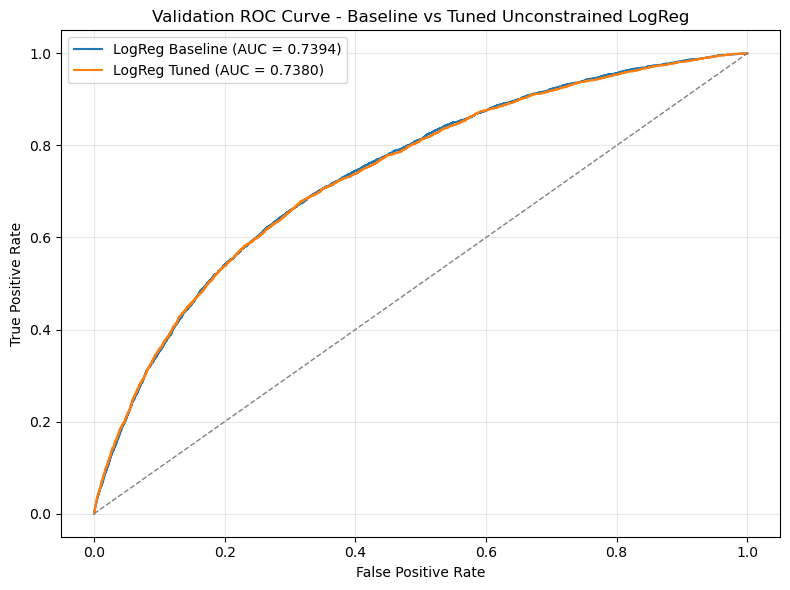

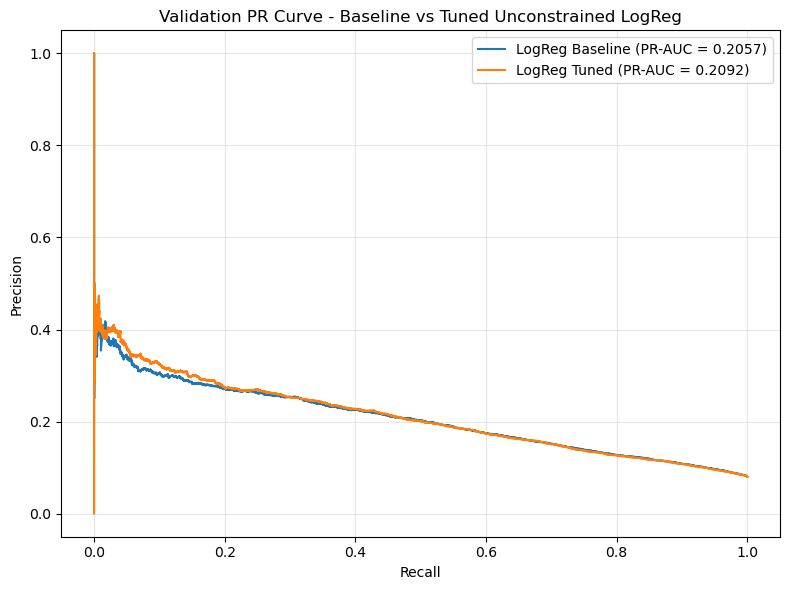

In [20]:
plot_roc_curves(
    curves_dict={
        "LogReg Baseline": (y_val, baseline_val_prob),
        "LogReg Tuned":    (y_val, tuned_unc_val_prob),
    },
    title="Validation ROC Curve - Baseline vs Tuned Unconstrained LogReg",
)
plot_pr_curves(
    curves_dict={
        "LogReg Baseline": (y_val, baseline_val_prob),
        "LogReg Tuned":    (y_val, tuned_unc_val_prob),
    },
    title="Validation PR Curve - Baseline vs Tuned Unconstrained LogReg",
)

In [21]:
display(unc_validation_compare_df)

,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_baseline,validation,0.205673,0.739436,0.206016,0.359193
1,logreg_unconstrained_tuned,validation,0.209218,0.738050,0.069281,0.361685


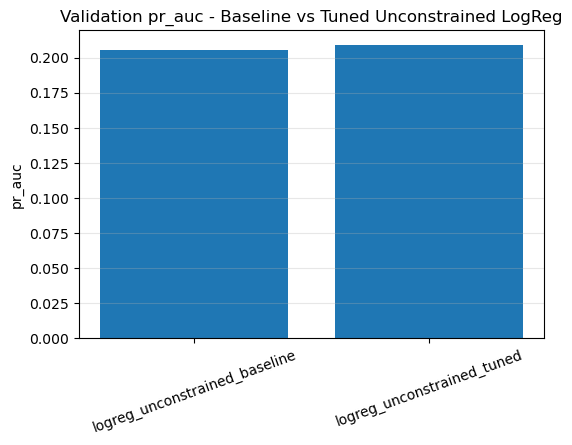

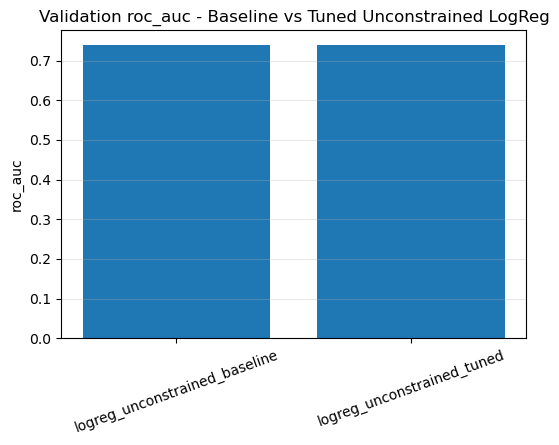

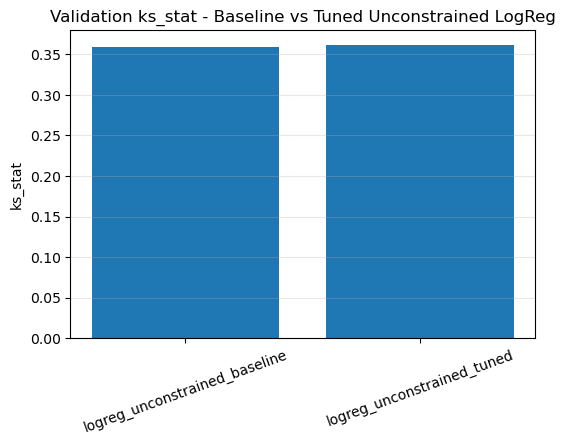

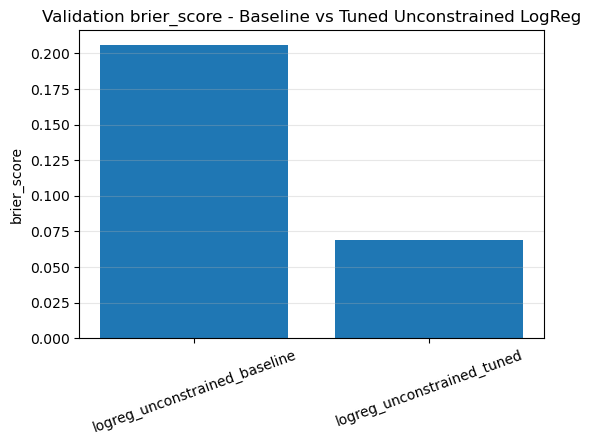

In [22]:
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(6, 4))
    plt.bar(unc_validation_compare_df["model_name"], unc_validation_compare_df[metric])
    plt.title(f"Validation {metric} - Baseline vs Tuned Unconstrained LogReg")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

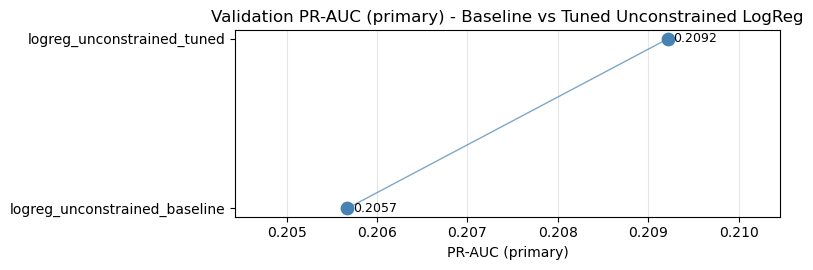

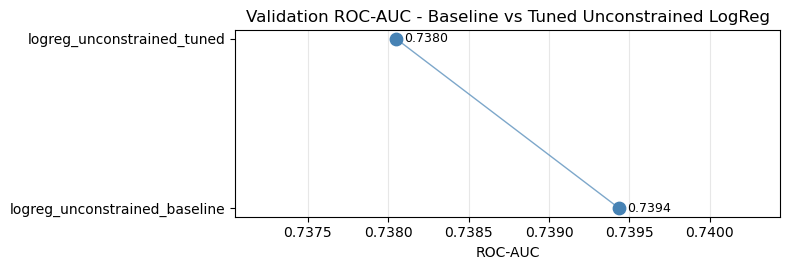

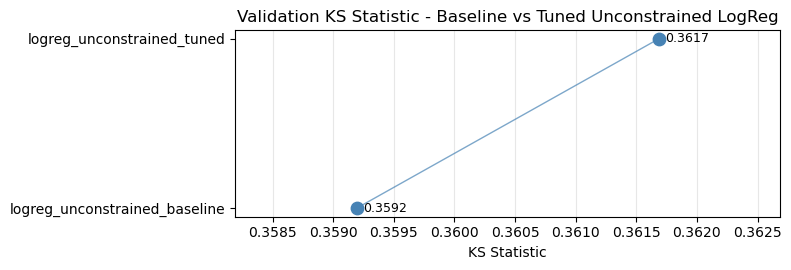

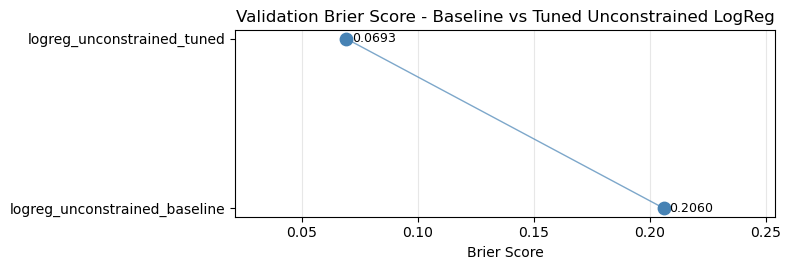

In [23]:
# Dot-plot: makes small metric differences between baseline and tuned visible
for metric, label in [
    ('pr_auc',      'PR-AUC (primary)'),
    ('roc_auc',     'ROC-AUC'),
    ('ks_stat',     'KS Statistic'),
    ('brier_score', 'Brier Score'),
]:
    plot_two_model_comparison(
        compare_df=unc_validation_compare_df,
        value_col=metric,
        title=f'Validation {label} - Baseline vs Tuned Unconstrained LogReg',
        x_label=label,
        as_percent=False,
        decimals=4,
    )

## CONSTRAINED LOGISTIC REGRESSION MODEL

Scorecard-style logistic regression with two structural constraints:
1. **Monotonic binning via WoE encoding** — continuous features with a clear economic direction
   are transformed using Weight of Evidence (WoE) binning with monotonicity enforced by
   isotonic regression
2. **Additive structure** — naturally satisfied by logistic regression (linear in log-odds)

Two runs:
- **Fixed** — same hyperparameters as the best unconstrained model (fair comparison)
- **Retuned** — fresh grid search to find the best achievable constrained performance

### Constrained Preprocessing — Monotonic WoE Encoding



WoE encodes each feature as a monotonic transformation of its empirical log-odds relationship with default.  
Bin WoE values are post-processed by isotonic regression to guarantee monotonic ordering.

WoE per bin = log( P(default | bin) / P(non-default | bin) )  

**Fit on training data only** — applied to validate/test without refitting to prevent leakage.  
Missing values receive their own `MISSING` bin WoE computed from NaN rows in training data.

In [24]:
# Monotonic direction per feature (agreed by team)
# +1 = higher feature value -> higher default risk  -> WoE non-decreasing across bins
# -1 = higher feature value -> lower default risk   -> WoE non-increasing across bins
MONOTONIC_DIRECTIONS = {
    "AMT_INCOME_TOTAL":           -1,
    "DAYS_BIRTH":                 -1,
    "DAYS_EMPLOYED":              -1,
    "AMT_REQ_CREDIT_BUREAU_HOUR": +1,
    "AMT_REQ_CREDIT_BUREAU_DAY":  +1,
    "AMT_REQ_CREDIT_BUREAU_WEEK": +1,
    "AMT_REQ_CREDIT_BUREAU_MON":  +1,
    "AMT_REQ_CREDIT_BUREAU_QRT":  +1,
    "AMT_REQ_CREDIT_BUREAU_YEAR": +1,
    "EXT_SOURCE_1":               -1,
    "EXT_SOURCE_2":               -1,
    "EXT_SOURCE_3":               -1,
}

WOE_FEATURES    = list(MONOTONIC_DIRECTIONS.keys())
NON_WOE_NUMERIC = [col for col in numeric_columns if col not in WOE_FEATURES]

print(f"WoE-encoded features ({len(WOE_FEATURES)}):    {WOE_FEATURES}")
print(f"Non-WoE numeric features ({len(NON_WOE_NUMERIC)}): {NON_WOE_NUMERIC}")

WoE-encoded features (12):    ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
Non-WoE numeric features (11): ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']


In [25]:
class MonotonicWoEEncoder:
    """
    Encodes continuous features using Weight of Evidence (WoE) binning
    with monotonicity enforced via isotonic regression.

    Design decisions
    ----------------
    - Fit on training data only; apply saved mapping to val/test (no leakage)
    - Missing values receive their own WoE bin computed from NaN rows in training data
    - Monotonicity direction (+1 / -1) specified per feature based on business logic
    - Isotonic regression post-processes raw bin WoEs to guarantee monotonic ordering

    WoE formula per bin
    -------------------
    WoE = log( P(default | bin) / P(non-default | bin) )
    """

    def __init__(self, n_bins=10):
        self.n_bins       = n_bins      # Number of quantile bins per feature
        self.bin_edges_   = {}          # Fitted bin boundaries per feature
        self.woe_maps_    = {}          # bin_index -> monotonic WoE value per feature
        self.missing_woe_ = {}          # WoE for the NaN bin per feature

    def __repr__(self):
        fitted = len(self.woe_maps_) > 0
        return f'MonotonicWoEEncoder(n_bins={self.n_bins}, fitted={fitted})'

    def get_feature_names_out(self):
        """Return list of features that were WoE-encoded."""
        return list(self.woe_maps_.keys())

    def fit(self, X, y, monotonic_directions):
        self.monotonic_directions_ = monotonic_directions
        total_events     = float(y.sum())
        total_non_events = float((1 - y).sum())

        for feature, direction in monotonic_directions.items():
            col     = X[feature].copy().reset_index(drop=True)
            y_r     = y.reset_index(drop=True)
            is_miss = col.isna()

            # WoE for missing bin
            miss_e = float(y_r[is_miss].sum())
            miss_n = float((1 - y_r[is_miss]).sum())
            self.missing_woe_[feature] = float(
                np.log(max(miss_e / total_events, 1e-6) / max(miss_n / total_non_events, 1e-6))
            )

            # Quantile bin edges on non-missing values
            non_miss = col[~is_miss]
            edges    = np.unique(np.percentile(non_miss, np.linspace(0, 100, self.n_bins + 1)))
            edges[0], edges[-1] = -np.inf, np.inf
            self.bin_edges_[feature] = edges

            # Raw WoE per bin
            bin_idx = pd.cut(non_miss, bins=edges, labels=False, include_lowest=True)
            n_bins  = len(edges) - 1
            raw_woe = []
            for b in range(n_bins):
                mask = bin_idx == b
                b_e  = float(y_r[~is_miss][mask].sum())
                b_n  = float((1 - y_r[~is_miss][mask]).sum())
                raw_woe.append(float(
                    np.log(max(b_e / total_events, 1e-6) / max(b_n / total_non_events, 1e-6))
                ))

            # Enforce monotonicity via isotonic regression
            iso      = IsotonicRegression(increasing=(direction == 1))
            mono_woe = iso.fit_transform(list(range(n_bins)), raw_woe)
            self.woe_maps_[feature] = dict(zip(range(n_bins), mono_woe))

        return self

    def transform(self, X):
        X_out = X.copy()
        for feature, woe_map in self.woe_maps_.items():
            col     = X[feature].copy()
            is_miss = col.isna()
            edges   = self.bin_edges_[feature]
            bin_idx = pd.cut(col, bins=edges, labels=False, include_lowest=True)
            out     = bin_idx.map(woe_map)
            out[is_miss] = self.missing_woe_[feature]    # Assign missing-bin WoE
            X_out[feature] = out.fillna(0.0)             # Fallback: unseen bins -> 0
        return X_out

    def fit_transform(self, X, y, monotonic_directions):
        return self.fit(X, y, monotonic_directions).transform(X)

In [26]:
woe_encoder = MonotonicWoEEncoder(n_bins=10)
X_train_woe = woe_encoder.fit_transform(X_train, y_train, MONOTONIC_DIRECTIONS)
X_val_woe   = woe_encoder.transform(X_val)
X_test_woe  = woe_encoder.transform(X_test)

# Verify monotonicity
print("Monotonicity verification:")
for feature, direction in MONOTONIC_DIRECTIONS.items():
    woe_vals = list(woe_encoder.woe_maps_[feature].values())
    diffs    = np.diff(woe_vals)
    is_mono  = bool(np.all(diffs >= -1e-9)) if direction == 1 else bool(np.all(diffs <= 1e-9))
    print(f"  [{'OK' if is_mono else 'FAIL'}] {feature} ({'+'  if direction == 1 else '-'})")

Monotonicity verification:
  [OK] AMT_INCOME_TOTAL (-)
  [OK] DAYS_BIRTH (-)
  [OK] DAYS_EMPLOYED (-)
  [OK] AMT_REQ_CREDIT_BUREAU_HOUR (+)
  [OK] AMT_REQ_CREDIT_BUREAU_DAY (+)
  [OK] AMT_REQ_CREDIT_BUREAU_WEEK (+)
  [OK] AMT_REQ_CREDIT_BUREAU_MON (+)
  [OK] AMT_REQ_CREDIT_BUREAU_QRT (+)
  [OK] AMT_REQ_CREDIT_BUREAU_YEAR (+)
  [OK] EXT_SOURCE_1 (-)
  [OK] EXT_SOURCE_2 (-)
  [OK] EXT_SOURCE_3 (-)


##### WoE Bin Diagnostics

Save and display the fitted WoE values per bin per feature. This is the artefact you would share with a credit risk team or regulator to demonstrate that monotonicity is enforced.

In [27]:
# Build WoE bin table: one row per (feature, bin)
woe_rows = []
for feature, woe_map in woe_encoder.woe_maps_.items():
    for bin_idx, woe_val in woe_map.items():
        woe_rows.append({
            'feature':     feature,
            'bin':         bin_idx,
            'woe':         round(woe_val, 6),
            'direction':   MONOTONIC_DIRECTIONS[feature],
            'missing_woe': round(woe_encoder.missing_woe_[feature], 6),
        })

woe_bin_df  = pd.DataFrame(woe_rows)
WOE_BIN_CSV = LOGREG_OUTPUT_DIR / 'logreg_woe_bin_table.csv'
woe_bin_df.to_csv(WOE_BIN_CSV, index=False)
print(f'Saved: {WOE_BIN_CSV}')
print(f'WoE table: {woe_bin_df.shape[0]} rows | {woe_bin_df["feature"].nunique()} features')
display(woe_bin_df.head(20))

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_woe_bin_table.csv
WoE table: 72 rows | 12 features


,feature,bin,woe,direction,missing_woe
0,AMT_INCOME_TOTAL,0,0.066569,-1,0.0
1,AMT_INCOME_TOTAL,1,0.066569,-1,0.0
2,AMT_INCOME_TOTAL,2,0.066569,-1,0.0
3,AMT_INCOME_TOTAL,3,0.066569,-1,0.0
4,AMT_INCOME_TOTAL,4,0.066569,-1,0.0
5,AMT_INCOME_TOTAL,5,0.066569,-1,0.0
6,AMT_INCOME_TOTAL,6,0.057451,-1,0.0
7,AMT_INCOME_TOTAL,7,-0.041138,-1,0.0
8,AMT_INCOME_TOTAL,8,-0.146116,-1,0.0
9,AMT_INCOME_TOTAL,9,-0.313653,-1,0.0


In [28]:
# -- Impute + scale NON-WoE numeric features, then OHE categoricals ----------
# IMPORTANT: WoE-encoded features are already on a log-odds scale.
# Re-scaling them would distort the monotonicity enforced above.
# Only NON_WOE_NUMERIC features are imputed and scaled here.

con_imputer = SimpleImputer(strategy='median')  # Fit on train only
con_scaler  = StandardScaler()                  # Z-score for non-WoE numeric features

X_train_con = X_train_woe.copy()
X_val_con   = X_val_woe.copy()
X_test_con  = X_test_woe.copy()

# Impute non-WoE numeric columns (fit on train only)
X_train_con[NON_WOE_NUMERIC] = con_imputer.fit_transform(X_train_woe[NON_WOE_NUMERIC])
X_val_con[NON_WOE_NUMERIC]   = con_imputer.transform(X_val_woe[NON_WOE_NUMERIC])
X_test_con[NON_WOE_NUMERIC]  = con_imputer.transform(X_test_woe[NON_WOE_NUMERIC])

# Scale non-WoE numeric columns only (WoE features intentionally excluded)
X_train_con[NON_WOE_NUMERIC] = con_scaler.fit_transform(X_train_con[NON_WOE_NUMERIC])
X_val_con[NON_WOE_NUMERIC]   = con_scaler.transform(X_val_con[NON_WOE_NUMERIC])
X_test_con[NON_WOE_NUMERIC]  = con_scaler.transform(X_test_con[NON_WOE_NUMERIC])

# One-hot encode categorical columns
X_train_con = pd.get_dummies(X_train_con, columns=categorical_columns, drop_first=False, dtype=int)
X_val_con   = pd.get_dummies(X_val_con,   columns=categorical_columns, drop_first=False, dtype=int)
X_test_con  = pd.get_dummies(X_test_con,  columns=categorical_columns, drop_first=False, dtype=int)

# Align val/test schemas to training (unseen levels -> 0)
X_val_con  = X_val_con.reindex(columns=X_train_con.columns, fill_value=0)
X_test_con = X_test_con.reindex(columns=X_train_con.columns, fill_value=0)

print('Train/validate columns match:', list(X_train_con.columns) == list(X_val_con.columns))
print(f'\nFinal constrained shapes:')
print(f'  X_train_con: {X_train_con.shape}')
print(f'  X_val_con:   {X_val_con.shape}')
print(f'  X_test_con:  {X_test_con.shape}')

Train/validate columns match: True

Final constrained shapes:
  X_train_con: (215137, 129)
  X_val_con:   (46101, 129)
  X_test_con:  (46101, 129)


### Constrained Model — Fixed Hyperparameters

Uses the **same hyperparameters** as the best unconstrained model.  
This isolates the cost of the constraint from the effect of different hyperparameters.

In [29]:
# -- Load best unconstrained hyperparameters from saved CSV ------------------
# Using the same params isolates the WoE constraint effect from regularisation differences
unc_best_row   = pd.read_csv(UNC_SELECTED_CSV).iloc[0]
FIXED_C        = float(unc_best_row['C'])
FIXED_PENALTY  = str(unc_best_row['penalty'])
raw_cw         = unc_best_row['class_weight']
FIXED_CLASS_WT = None if pd.isna(raw_cw) else str(raw_cw)

print(f'Hyperparameters carried over from unconstrained model:')
print(f'  C={FIXED_C}, penalty={FIXED_PENALTY}, class_weight={FIXED_CLASS_WT!r}')

# -- Fit constrained model with fixed hyperparameters -------------------------
logreg_con_fixed = LogisticRegression(
    penalty=FIXED_PENALTY,
    C=FIXED_C,
    solver=SOLVER_MAP[FIXED_PENALTY],   # Solver determined by penalty type
    class_weight=FIXED_CLASS_WT,
    max_iter=1000,                      # Generous iteration budget
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
logreg_con_fixed.fit(X_train_con, y_train)

# -- Convergence check --------------------------------------------------------
if hasattr(logreg_con_fixed, 'n_iter_'):
    converged = all(n < logreg_con_fixed.max_iter for n in logreg_con_fixed.n_iter_)
    print(f'\nConverged: {converged} | Iterations used: {logreg_con_fixed.n_iter_}')

# -- Evaluate on validation ---------------------------------------------------
fixed_val_prob   = logreg_con_fixed.predict_proba(X_val_con)[:, 1]
fixed_val_result = evaluate_binary_model(
    model=logreg_con_fixed, X=X_val_con, y=y_val,
    split_name='validation', model_name='logreg_constrained_fixed',
)

# Add hyperparameter metadata (symmetric with retuned result row)
fixed_val_result.update({
    'C':            FIXED_C,
    'penalty':      FIXED_PENALTY,
    'class_weight': str(FIXED_CLASS_WT),
})

pd.DataFrame([fixed_val_result]).to_csv(CON_FIXED_CSV, index=False)
print(f"\nPR-AUC: {fixed_val_result['pr_auc']:.6f} | ROC-AUC: {fixed_val_result['roc_auc']:.6f}")
print(f'Saved: {CON_FIXED_CSV}')

Hyperparameters carried over from unconstrained model:
  C=100.0, penalty=l1, class_weight=None

Converged: False | Iterations used: [1000]

PR-AUC: 0.206855 | ROC-AUC: 0.737974
Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_fixed_selected_model_validation.csv


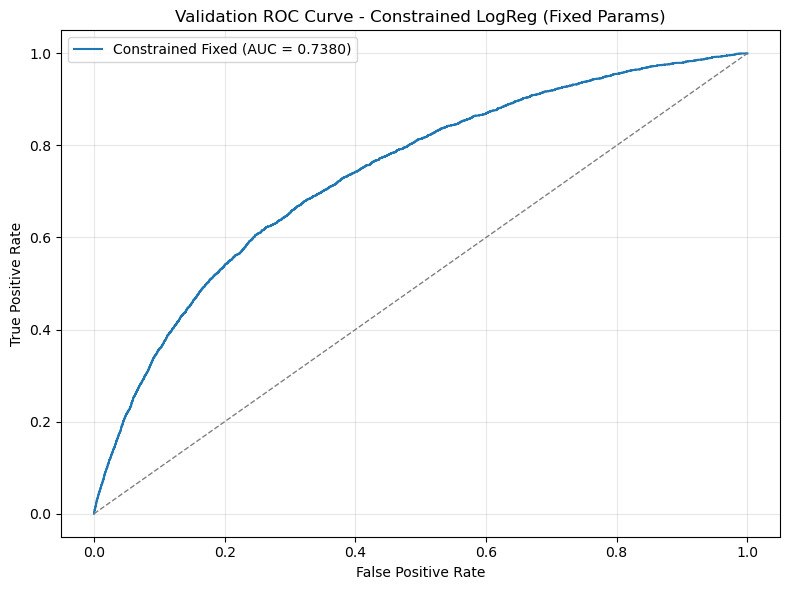

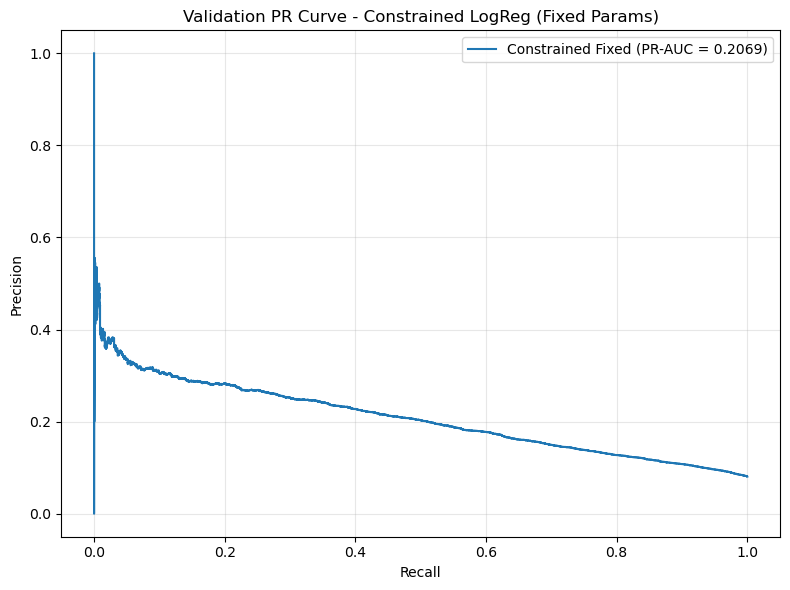

In [30]:
plot_roc_curves(
    curves_dict={"Constrained Fixed": (y_val, fixed_val_prob)},
    title="Validation ROC Curve - Constrained LogReg (Fixed Params)",
)
plot_pr_curves(
    curves_dict={"Constrained Fixed": (y_val, fixed_val_prob)},
    title="Validation PR Curve - Constrained LogReg (Fixed Params)",
)

### Constrained Model — Retuned Hyperparameters

Fresh grid search on the constrained model. Same search space as unconstrained.

In [31]:
con_search_results = []
con_search_models  = {}

for i, combo in enumerate(search_combinations, start=1):
    candidate_params = dict(zip(search_param_names, combo))
    candidate_name   = f"logreg_con_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name,
        X_train_r=X_train_con,
        X_val_r=X_val_con,
    )
    con_search_models[candidate_name] = fitted_model
    con_search_results.append(validation_result)

con_search_df = pd.DataFrame(con_search_results).sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

con_search_df.to_csv(CON_RETUNED_TUNING_CSV, index=False)
print(f"Saved: {CON_RETUNED_TUNING_CSV}")
con_search_df.head(10)

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_retuned_tuning_results_validation.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat,C,penalty,class_weight
0,logreg_con_candidate_6,validation,0.207391,0.738568,0.069314,0.360875,0.10,l1,None
1,logreg_con_candidate_10,validation,0.206987,0.738224,0.069337,0.360006,1.00,l1,None
2,logreg_con_candidate_14,validation,0.206873,0.738053,0.069343,0.359346,10.00,l1,None
3,logreg_con_candidate_18,validation,0.206736,0.738032,0.069343,0.359275,100.00,l1,None
4,logreg_con_candidate_16,validation,0.204386,0.735440,0.069463,0.355583,10.00,l2,None
5,logreg_con_candidate_20,validation,0.204386,0.735440,0.069463,0.355536,100.00,l2,None
6,logreg_con_candidate_12,validation,0.204378,0.735440,0.069463,0.355630,1.00,l2,None
7,logreg_con_candidate_8,validation,0.204358,0.735441,0.069463,0.355300,0.10,l2,None
8,logreg_con_candidate_4,validation,0.204099,0.735432,0.069465,0.355786,0.01,l2,None
9,logreg_con_candidate_2,validation,0.203785,0.735471,0.069460,0.358425,0.01,l1,None


In [32]:
best_con_name    = con_search_df.loc[0, "model_name"]
best_logreg_con  = con_search_models[best_con_name]

print("Selected retuned constrained logistic regression model:")
print(f"  Candidate name:     {best_con_name}")
print(f"  C:                  {con_search_df.loc[0, 'C']}")
print(f"  Penalty:            {con_search_df.loc[0, 'penalty']}")
print(f"  Class weight:       {con_search_df.loc[0, 'class_weight']}")
print(f"  Validation PR-AUC:  {con_search_df.loc[0, 'pr_auc']:.6f}")
print(f"  Validation ROC-AUC: {con_search_df.loc[0, 'roc_auc']:.6f}")
print(f"  Validation KS:      {con_search_df.loc[0, 'ks_stat']:.6f}")
print(f"  Validation Brier:   {con_search_df.loc[0, 'brier_score']:.6f}")

con_search_df.head(1).to_csv(CON_RETUNED_SELECTED_CSV, index=False)
print(f"\nSaved: {CON_RETUNED_SELECTED_CSV}")

Selected retuned constrained logistic regression model:
  Candidate name:     logreg_con_candidate_6
  C:                  0.1
  Penalty:            l1
  Class weight:       None
  Validation PR-AUC:  0.207391
  Validation ROC-AUC: 0.738568
  Validation KS:      0.360875
  Validation Brier:   0.069314

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_retuned_selected_model_validation.csv


In [33]:
retuned_val_result = evaluate_binary_model(
    model=best_logreg_con, X=X_val_con, y=y_val,
    split_name='validation', model_name='logreg_constrained_retuned',
)

# Add hyperparameter metadata (symmetric with fixed result row)
retuned_val_result.update({
    'C':            con_search_df.loc[0, 'C'],
    'penalty':      con_search_df.loc[0, 'penalty'],
    'class_weight': str(con_search_df.loc[0, 'class_weight']),
})

retuned_val_prob = best_logreg_con.predict_proba(X_val_con)[:, 1]

con_validation_compare_df = pd.DataFrame([fixed_val_result, retuned_val_result])
con_validation_compare_df.to_csv(CON_VALIDATION_CMP_CSV, index=False)
print(f'Saved: {CON_VALIDATION_CMP_CSV}')

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_constrained_validation_comparison.csv


### Results: Constrained Fixed vs Constrained Retuned

**What this comparison answers:** Does retuning the constrained model recover any performance lost from imposing the WoE monotonicity constraint?

**What to look for:**
- If Fixed ≈ Retuned: the hyperparameters transfer well; the constraint cost is mostly irreducible
- If Retuned > Fixed: the optimal regularisation regime changes once WoE encoding is applied,
  and the retuning step was worthwhile

Both constrained variants are compared against the unconstrained tuned model in the Final Comparison.

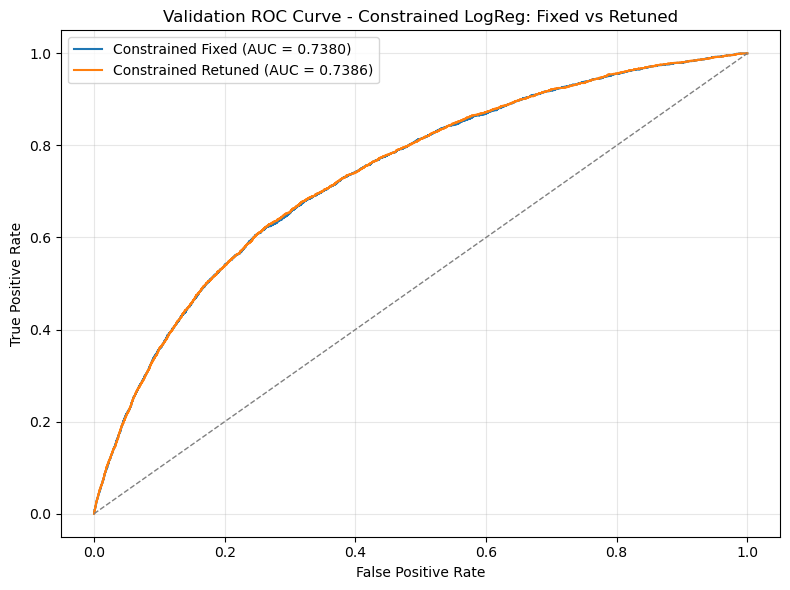

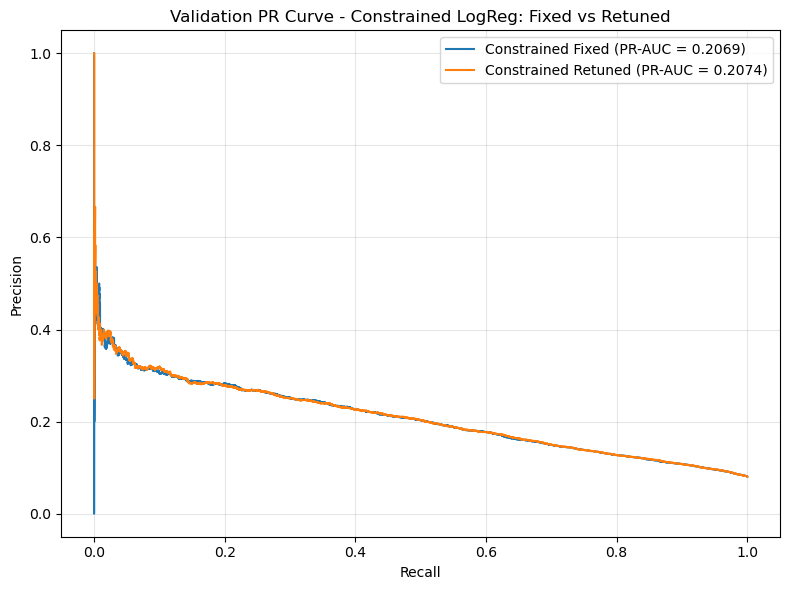

In [34]:
plot_roc_curves(
    curves_dict={
        "Constrained Fixed":   (y_val, fixed_val_prob),
        "Constrained Retuned": (y_val, retuned_val_prob),
    },
    title="Validation ROC Curve - Constrained LogReg: Fixed vs Retuned",
)
plot_pr_curves(
    curves_dict={
        "Constrained Fixed":   (y_val, fixed_val_prob),
        "Constrained Retuned": (y_val, retuned_val_prob),
    },
    title="Validation PR Curve - Constrained LogReg: Fixed vs Retuned",
)

In [35]:
display(con_validation_compare_df)

,model_name,split,pr_auc,roc_auc,brier_score,ks_stat,C,penalty,class_weight
0,logreg_constrained_fixed,validation,0.206855,0.737974,0.069339,0.358950,100.0,l1,None
1,logreg_constrained_retuned,validation,0.207391,0.738568,0.069314,0.360875,0.1,l1,None


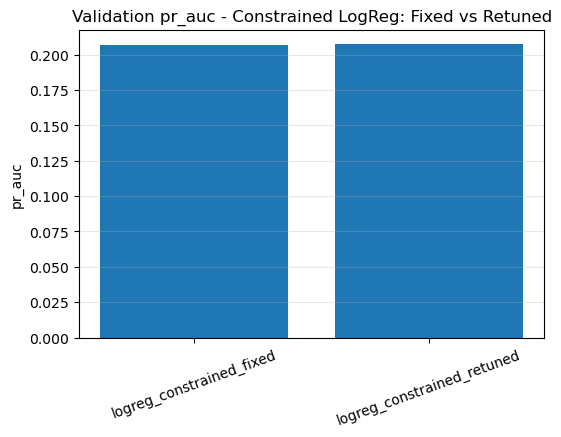

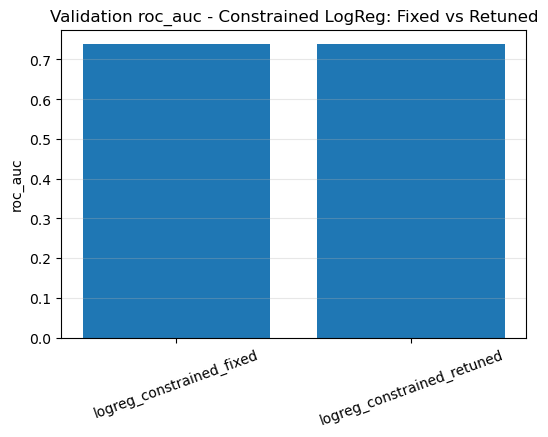

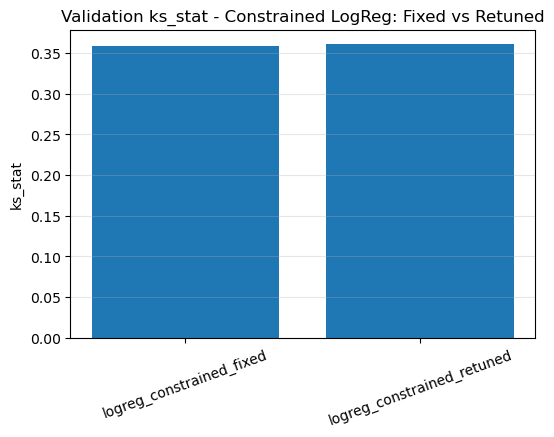

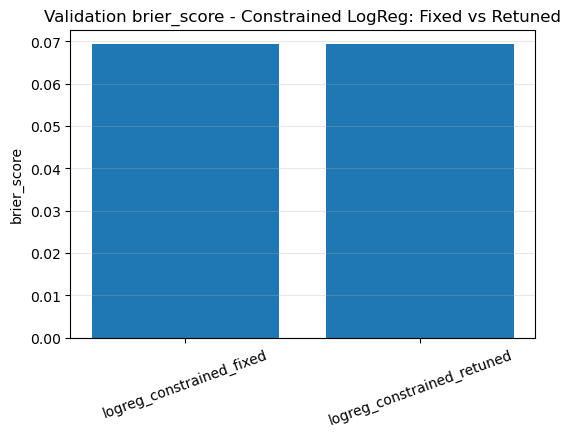

In [36]:
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(6, 4))
    plt.bar(con_validation_compare_df["model_name"], con_validation_compare_df[metric])
    plt.title(f"Validation {metric} - Constrained LogReg: Fixed vs Retuned")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

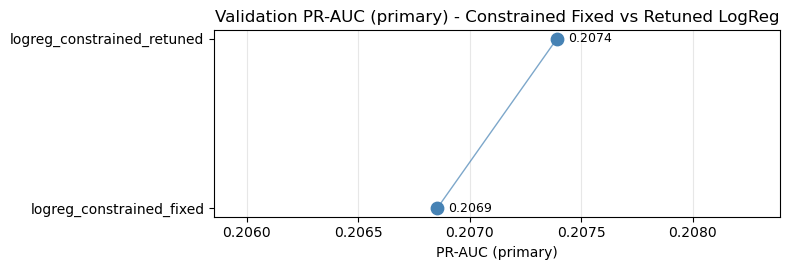

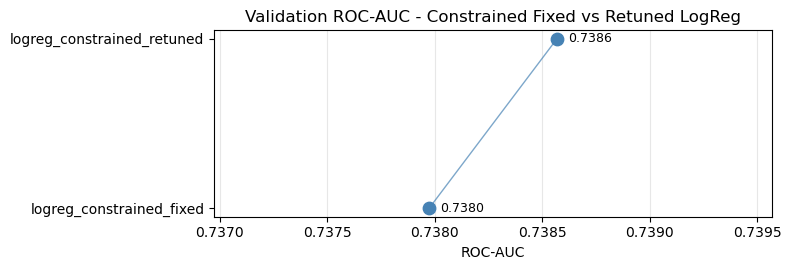

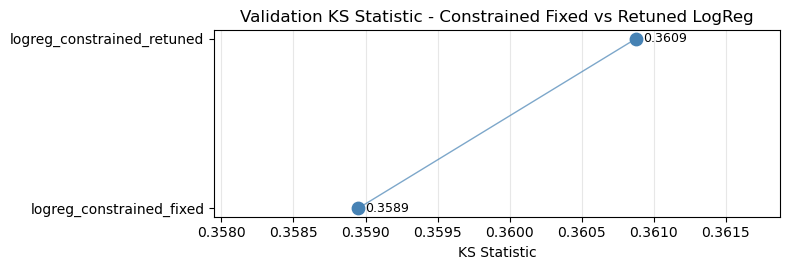

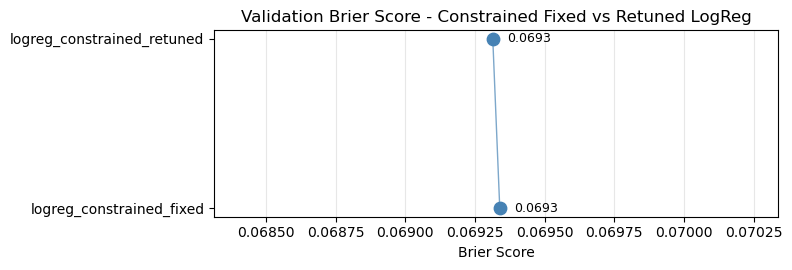

In [37]:
# Dot-plot: constrained fixed vs retuned
for metric, label in [
    ('pr_auc',      'PR-AUC (primary)'),
    ('roc_auc',     'ROC-AUC'),
    ('ks_stat',     'KS Statistic'),
    ('brier_score', 'Brier Score'),
]:
    plot_two_model_comparison(
        compare_df=con_validation_compare_df,
        value_col=metric,
        title=f'Validation {label} - Constrained Fixed vs Retuned LogReg',
        x_label=label,
        as_percent=False,
        decimals=4,
    )

## FINAL COMPARISON

Side-by-side comparison of all three model variants on the validation set.

| Model | Description |
|---|---|
| `logreg_unconstrained_tuned` | Best unconstrained model |
| `logreg_constrained_fixed` | Constrained — same params as unconstrained |
| `logreg_constrained_retuned` | Constrained — independently retuned |

In [38]:
final_comparison_df = pd.DataFrame([
    evaluate_binary_model(best_logreg_unc, X_val_unc, y_val, "validation", "logreg_unconstrained_tuned"),
    evaluate_binary_model(logreg_con_fixed, X_val_con, y_val, "validation", "logreg_constrained_fixed"),
    evaluate_binary_model(best_logreg_con,  X_val_con, y_val, "validation", "logreg_constrained_retuned"),
])

final_comparison_df.to_csv(FINAL_COMPARISON_CSV, index=False)
print(f"Saved: {FINAL_COMPARISON_CSV}")
display(final_comparison_df)

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_final_comparison.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_tuned,validation,0.209218,0.738050,0.069281,0.361685
1,logreg_constrained_fixed,validation,0.206855,0.737974,0.069339,0.358950
2,logreg_constrained_retuned,validation,0.207391,0.738568,0.069314,0.360875


In [39]:
unc_row = final_comparison_df[final_comparison_df["model_name"] == "logreg_unconstrained_tuned"].iloc[0]

delta_rows = []
for _, row in final_comparison_df[final_comparison_df["model_name"] != "logreg_unconstrained_tuned"].iterrows():
    delta_rows.append({
        "model_name":        row["model_name"],
        "delta_pr_auc":      round(row["pr_auc"]     - unc_row["pr_auc"],      6),
        "delta_roc_auc":     round(row["roc_auc"]    - unc_row["roc_auc"],     6),
        "delta_ks_stat":     round(row["ks_stat"]    - unc_row["ks_stat"],     6),
        "delta_brier_score": round(row["brier_score"] - unc_row["brier_score"], 6),
    })

print("Performance delta vs unconstrained (negative = loss from constraint):")
display(pd.DataFrame(delta_rows))

Performance delta vs unconstrained (negative = loss from constraint):


,model_name,delta_pr_auc,delta_roc_auc,delta_ks_stat,delta_brier_score
0,logreg_constrained_fixed,-0.002363,-0.000076,-0.002735,0.000058
1,logreg_constrained_retuned,-0.001827,0.000519,-0.000811,0.000033


### Interpretation - Final Validation Comparison

The delta table above shows the performance gap of each constrained variant versus the unconstrained tuned model. Negative values mean the constraint reduced performance.

**Three questions this answers:**

1. **Raw cost of the WoE constraint:** Compare `logreg_constrained_fixed` vs `logreg_unconstrained_tuned` — same hyperparameters, only preprocessing differs.

2. **Can retuning recover the loss?** Compare `logreg_constrained_retuned` vs `logreg_constrained_fixed` — if the delta shrinks, retuning helped.

3. **Is the PR-AUC cost acceptable for compliance?** A small drop (e.g. < 0.005) is typically acceptable in exchange for the interpretability and regulatory alignment that monotonic WoE encoding provides.

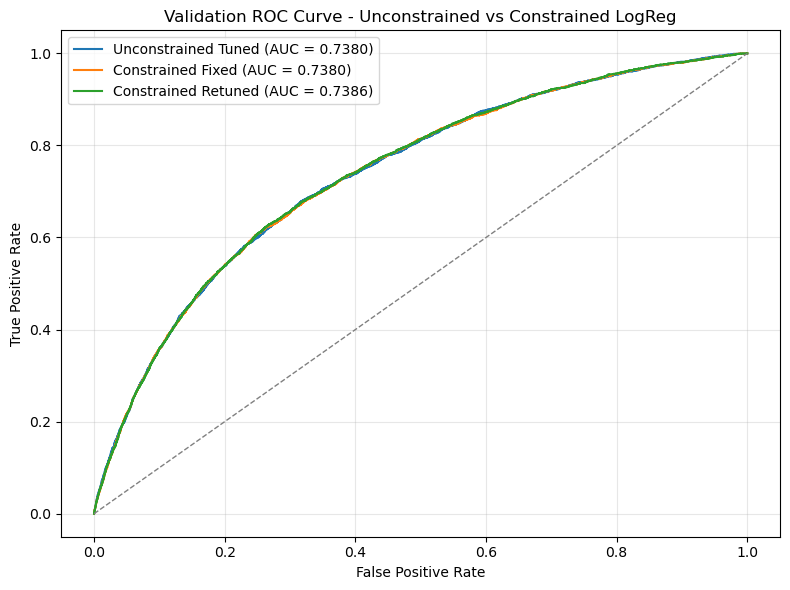

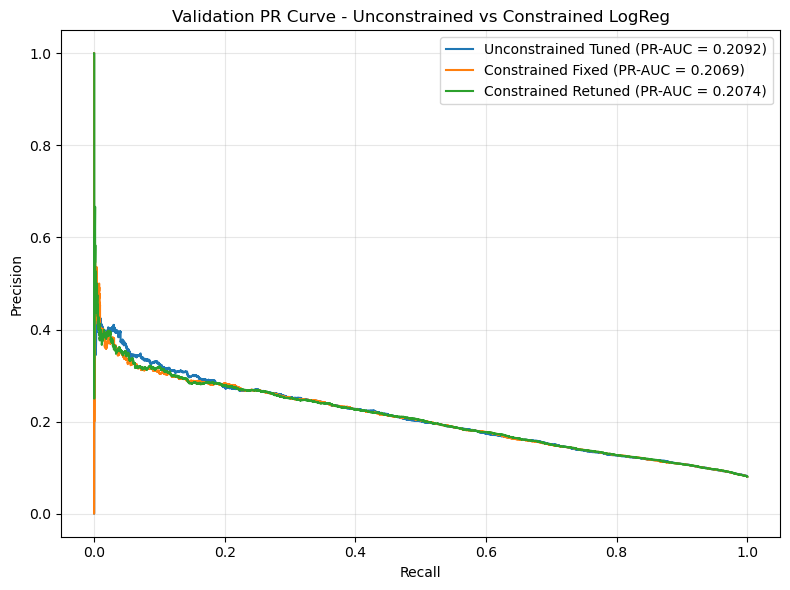

In [40]:
plot_roc_curves(
    curves_dict={
        "Unconstrained Tuned":   (y_val, tuned_unc_val_prob),
        "Constrained Fixed":     (y_val, fixed_val_prob),
        "Constrained Retuned":   (y_val, retuned_val_prob),
    },
    title="Validation ROC Curve - Unconstrained vs Constrained LogReg",
)
plot_pr_curves(
    curves_dict={
        "Unconstrained Tuned":   (y_val, tuned_unc_val_prob),
        "Constrained Fixed":     (y_val, fixed_val_prob),
        "Constrained Retuned":   (y_val, retuned_val_prob),
    },
    title="Validation PR Curve - Unconstrained vs Constrained LogReg",
)

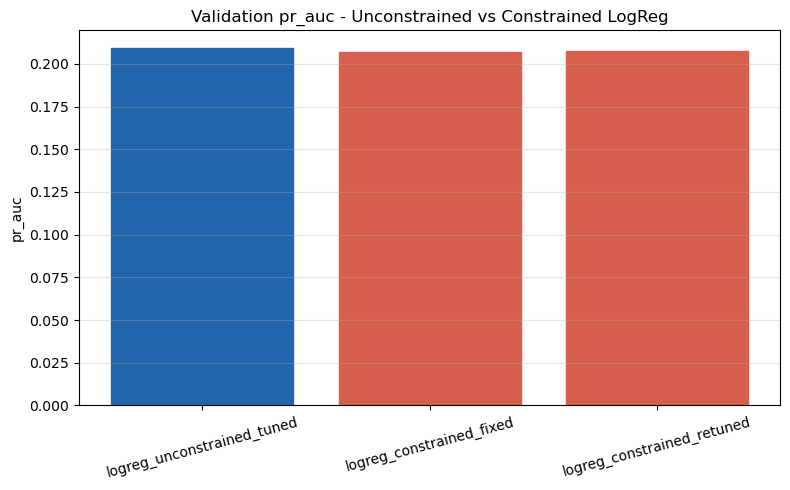

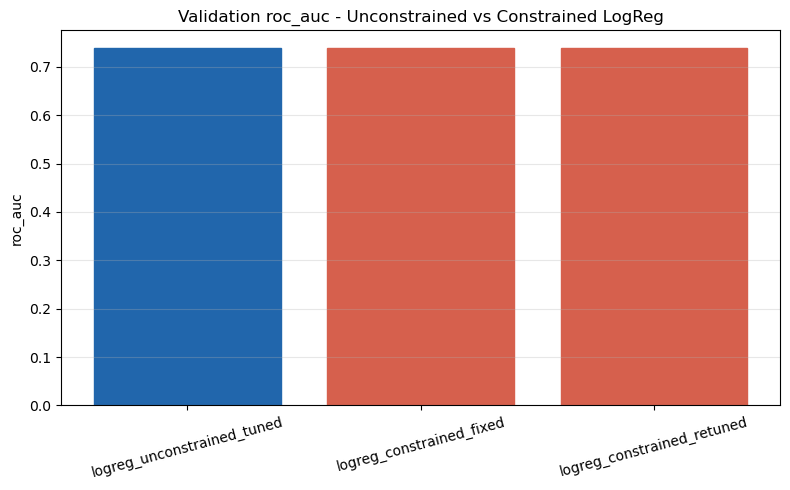

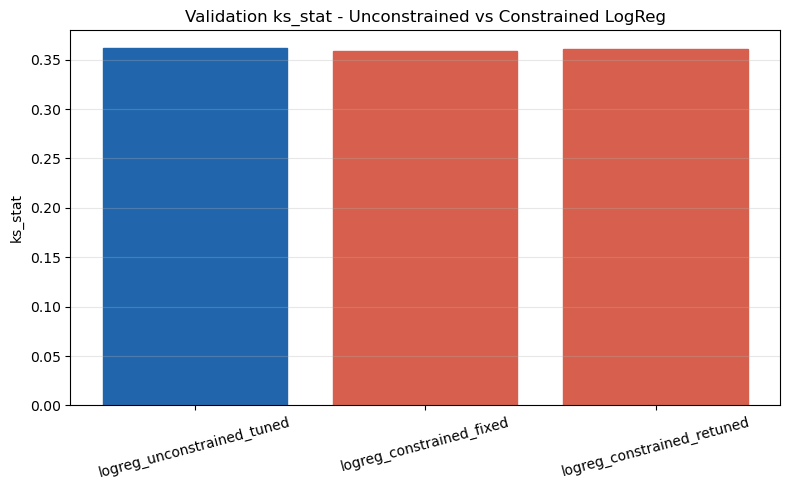

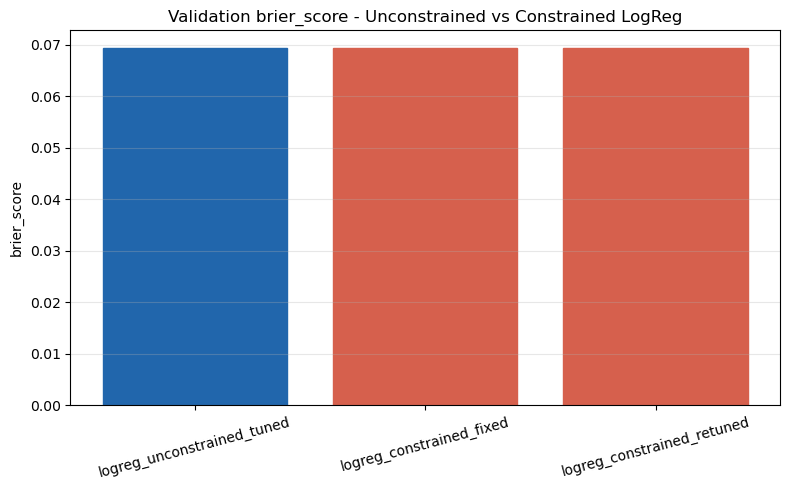

In [41]:
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(final_comparison_df["model_name"], final_comparison_df[metric])
    for bar, name in zip(bars, final_comparison_df["model_name"]):
        bar.set_color("#2166ac" if name == "logreg_unconstrained_tuned" else "#d6604d")
    plt.title(f"Validation {metric} - Unconstrained vs Constrained LogReg")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(LOGREG_OUTPUT_DIR / f"logreg_comparison_{metric}.png", dpi=150)
    plt.show()

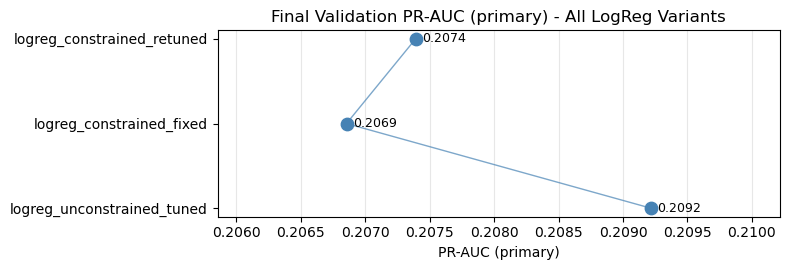

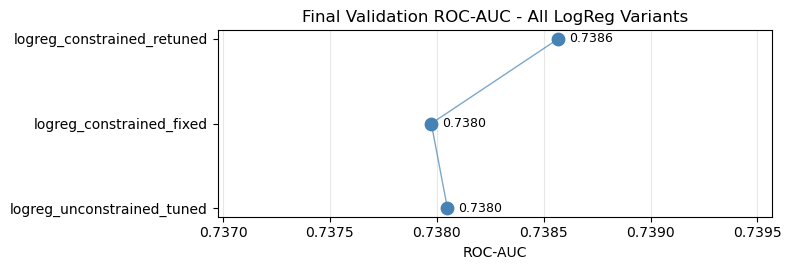

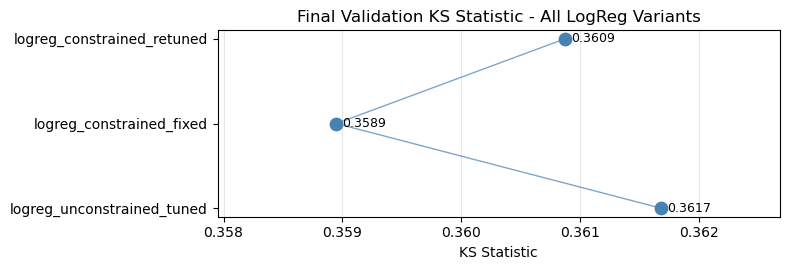

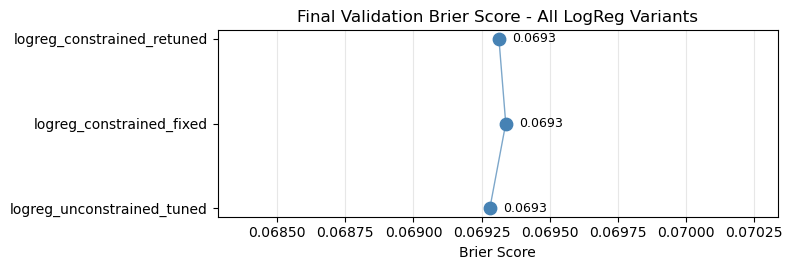

In [42]:
# Dot-plot: all three models - final validation metric comparison
for metric, label in [
    ('pr_auc',      'PR-AUC (primary)'),
    ('roc_auc',     'ROC-AUC'),
    ('ks_stat',     'KS Statistic'),
    ('brier_score', 'Brier Score'),
]:
    plot_two_model_comparison(
        compare_df=final_comparison_df,
        value_col=metric,
        title=f'Final Validation {label} - All LogReg Variants',
        x_label=label,
        as_percent=False,
        decimals=4,
    )

## FINAL TEST SET EVALUATION

All three logistic regression model variants are now scored on the held-out test set.
The test set has not been used at any point during training or hyperparameter selection.

| Model | Preprocessing | Hyperparameters |
|---|---|---|
| `logreg_unconstrained_tuned` | Standard impute + scale + OHE | Tuned on validation |
| `logreg_constrained_fixed` | WoE + impute + scale + OHE | Same as unconstrained |
| `logreg_constrained_retuned` | WoE + impute + scale + OHE | Independently retuned |

Saved: /Users/ankitasamantaray/Desktop/credit-risk-model-constraint-eval/output/logreg/logreg_final_test_results.csv


,model_name,split,pr_auc,roc_auc,brier_score,ks_stat
0,logreg_unconstrained_tuned,test,0.209982,0.736075,0.069308,0.358021
1,logreg_constrained_fixed,test,0.211184,0.737367,0.069223,0.363606
2,logreg_constrained_retuned,test,0.211073,0.737137,0.069238,0.363371



Validation vs Test (negative delta = drop on test):


,model_name,val_pr_auc,test_pr_auc,delta_pr_auc,delta_roc_auc,delta_ks_stat,delta_brier_score
0,logreg_unconstrained_tuned,0.209218,0.209982,0.000764,-0.001975,-0.003664,0.000027
1,logreg_constrained_fixed,0.206855,0.211184,0.004329,-0.000607,0.004656,-0.000116
2,logreg_constrained_retuned,0.207391,0.211073,0.003681,-0.001432,0.002496,-0.000076


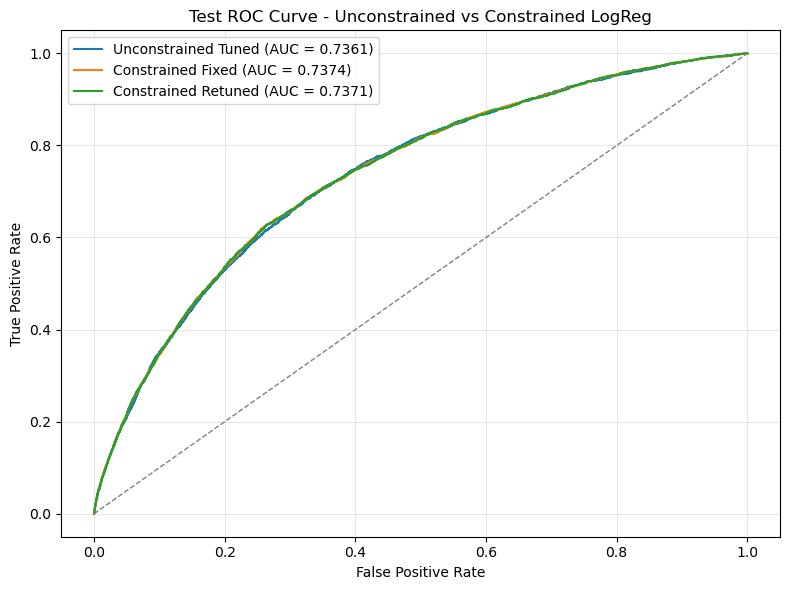

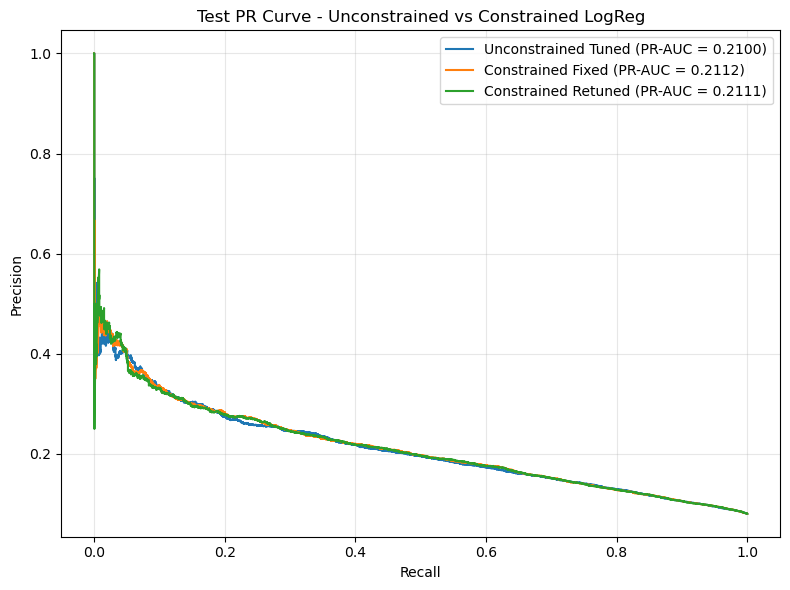

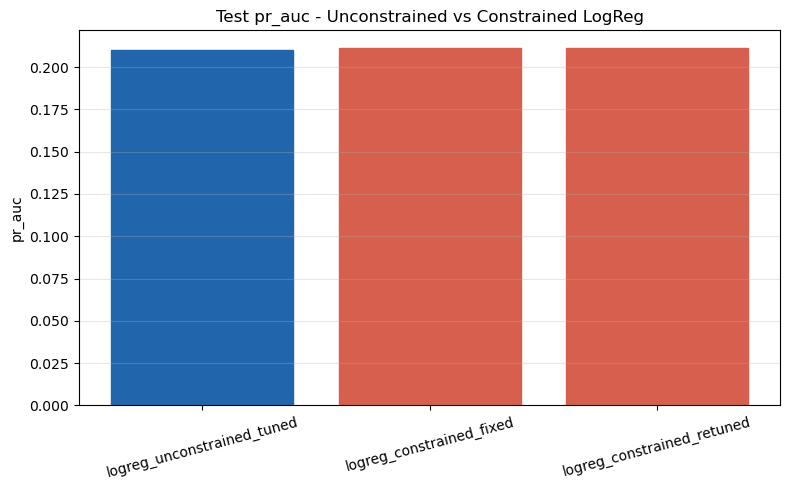

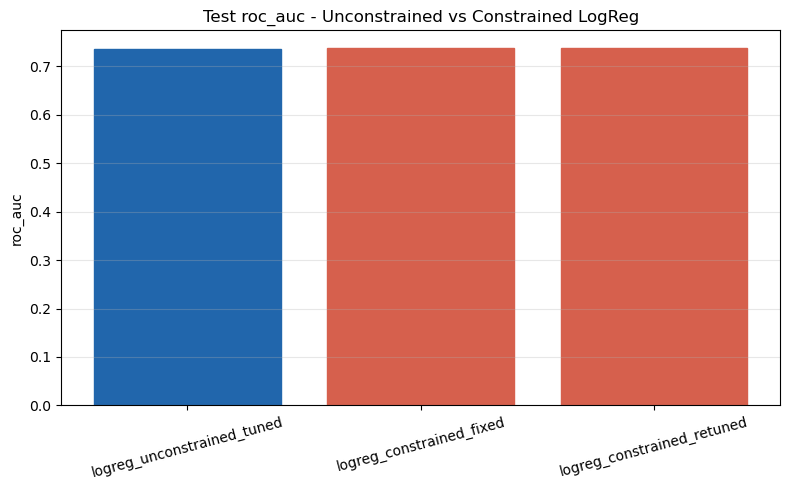

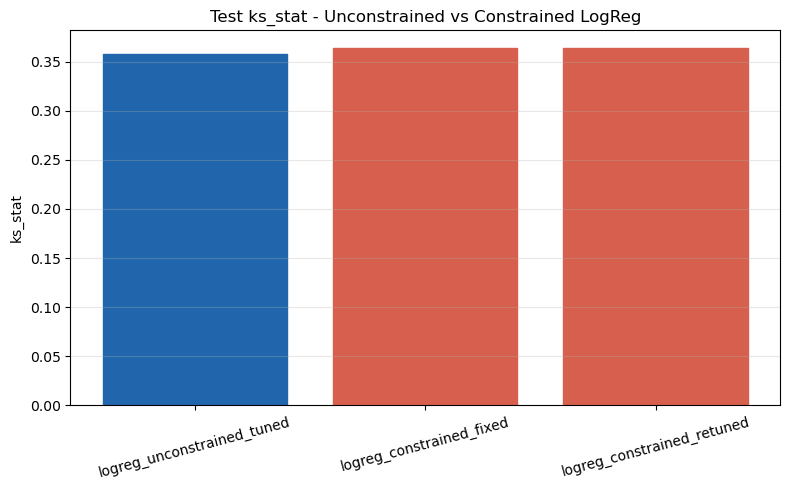

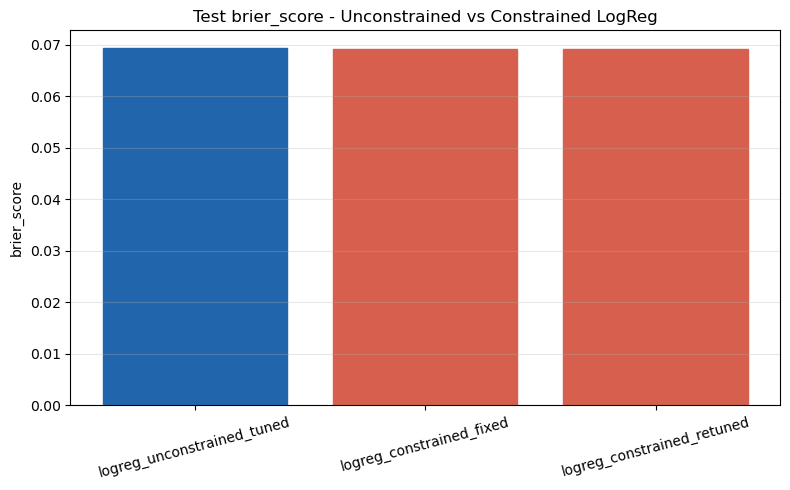

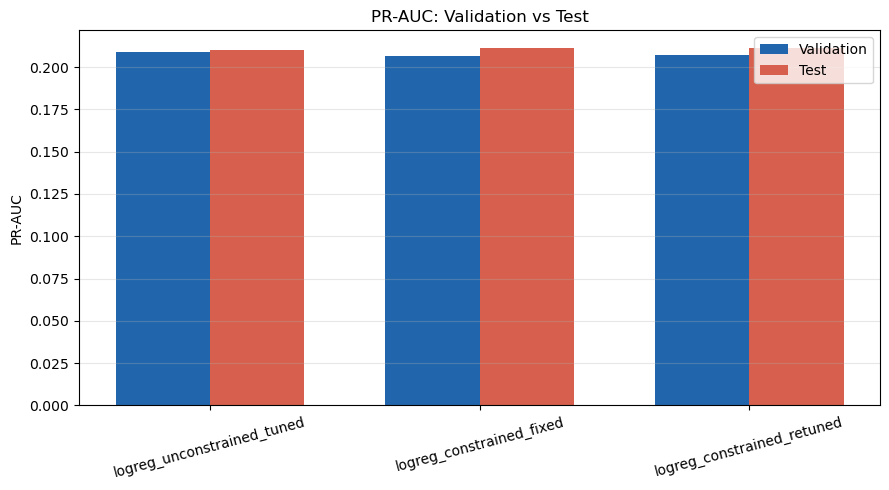

In [43]:
TEST_RESULTS_CSV = LOGREG_OUTPUT_DIR / "logreg_final_test_results.csv"
TEST_DELTA_CSV   = LOGREG_OUTPUT_DIR / "logreg_final_test_vs_validation.csv"

# Score all three selected models on the test set
test_results_df = pd.DataFrame([
    evaluate_binary_model(best_logreg_unc, X_test_unc, y_test, "test", "logreg_unconstrained_tuned"),
    evaluate_binary_model(logreg_con_fixed, X_test_con, y_test, "test", "logreg_constrained_fixed"),
    evaluate_binary_model(best_logreg_con,  X_test_con, y_test, "test", "logreg_constrained_retuned"),
])

test_results_df.to_csv(TEST_RESULTS_CSV, index=False)
print(f"Saved: {TEST_RESULTS_CSV}")
display(test_results_df)

# Cache predicted probabilities for plotting
test_unc_prob     = best_logreg_unc.predict_proba(X_test_unc)[:, 1]
test_fixed_prob   = logreg_con_fixed.predict_proba(X_test_con)[:, 1]
test_retuned_prob = best_logreg_con.predict_proba(X_test_con)[:, 1]

### Validation vs Test — check for overfitting / generalization gap
val_vs_test_rows = []
for model_name in test_results_df["model_name"]:
    val_row  = final_comparison_df[final_comparison_df["model_name"] == model_name].iloc[0]
    test_row = test_results_df[test_results_df["model_name"] == model_name].iloc[0]
    val_vs_test_rows.append({
        "model_name":        model_name,
        "val_pr_auc":        round(val_row["pr_auc"], 6),
        "test_pr_auc":       round(test_row["pr_auc"], 6),
        "delta_pr_auc":      round(test_row["pr_auc"]      - val_row["pr_auc"], 6),
        "delta_roc_auc":     round(test_row["roc_auc"]     - val_row["roc_auc"], 6),
        "delta_ks_stat":     round(test_row["ks_stat"]     - val_row["ks_stat"], 6),
        "delta_brier_score": round(test_row["brier_score"] - val_row["brier_score"], 6),
    })

val_vs_test_df = pd.DataFrame(val_vs_test_rows)
val_vs_test_df.to_csv(TEST_DELTA_CSV, index=False)
print(f"\nValidation vs Test (negative delta = drop on test):")
display(val_vs_test_df)

### Plots — ROC and PR curves on test set
plot_roc_curves(
    curves_dict={
        "Unconstrained Tuned": (y_test, test_unc_prob),
        "Constrained Fixed":   (y_test, test_fixed_prob),
        "Constrained Retuned": (y_test, test_retuned_prob),
    },
    title="Test ROC Curve - Unconstrained vs Constrained LogReg",
)
plot_pr_curves(
    curves_dict={
        "Unconstrained Tuned": (y_test, test_unc_prob),
        "Constrained Fixed":   (y_test, test_fixed_prob),
        "Constrained Retuned": (y_test, test_retuned_prob),
    },
    title="Test PR Curve - Unconstrained vs Constrained LogReg",
)

### Bar charts — per-metric comparison on test set
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plt.figure(figsize=(8, 5))
    bars = plt.bar(test_results_df["model_name"], test_results_df[metric])
    for bar, name in zip(bars, test_results_df["model_name"]):
        bar.set_color("#2166ac" if name == "logreg_unconstrained_tuned" else "#d6604d")
    plt.title(f"Test {metric} - Unconstrained vs Constrained LogReg")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(LOGREG_OUTPUT_DIR / f"logreg_test_{metric}.png", dpi=150)
    plt.show()

### Side-by-side validation vs test bar chart (PR-AUC, the primary metric)
combined = final_comparison_df[["model_name", "pr_auc"]].rename(columns={"pr_auc": "validation"}).merge(
    test_results_df[["model_name", "pr_auc"]].rename(columns={"pr_auc": "test"}),
    on="model_name",
)

x       = np.arange(len(combined))
width   = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width/2, combined["validation"], width, label="Validation", color="#2166ac")
plt.bar(x + width/2, combined["test"],       width, label="Test",       color="#d6604d")
plt.xticks(x, combined["model_name"], rotation=15)
plt.ylabel("PR-AUC")
plt.title("PR-AUC: Validation vs Test")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(LOGREG_OUTPUT_DIR / "logreg_val_vs_test_pr_auc.png", dpi=150)
plt.show()

## BUSINESS IMPACT ANALYSIS

Standard model metrics measure ranking quality in aggregate. This section translates the constrained-vs-unconstrained performance gap into two concrete business operating-point views:

1. **Fixed approval rate** - if the lender approves the same share of applications, how many more defaults does the constrained model admit?

2. **Fixed observed bad-rate target** - if the lender holds portfolio credit quality constant, how much approval volume must the constrained model sacrifice?

Results are structured identically to the XGBoost business analysis, enabling a direct cross-architecture comparison.

In [44]:
def evaluate_operating_point(y_true, y_score, approval_rate=None, bad_rate_target=None):
    """
    Compute business-facing operating-point metrics for a scored portfolio.

    Two modes:
    - approval_rate: Fix fraction approved; measure resulting defaults
    - bad_rate_target: Fix observed default rate among approved; measure approval volume
    """
    y_true  = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # Sort applicants safest first (lowest predicted risk approved first)
    order    = np.argsort(y_score)
    sorted_y = y_true[order]
    n_obs    = len(sorted_y)

    if approval_rate is not None and bad_rate_target is None:
        # Mode 1: fixed approval rate
        n_approve = max(1, min(int(np.floor(approval_rate * n_obs)), n_obs))

    elif bad_rate_target is not None and approval_rate is None:
        # Mode 2: fixed observed bad-rate target
        cum_defaults  = np.cumsum(sorted_y)
        candidate_n   = np.arange(1, n_obs + 1)
        cum_bad_rates = cum_defaults / candidate_n
        feasible      = candidate_n[cum_bad_rates <= bad_rate_target]
        n_approve     = int(feasible.max()) if len(feasible) > 0 else 1
    else:
        raise ValueError('Provide exactly one of approval_rate or bad_rate_target.')

    approved_y        = sorted_y[:n_approve]
    approved_defaults = int(approved_y.sum())
    observed_bad_rate = approved_defaults / n_approve if n_approve > 0 else np.nan

    return {
        'n_approved':        n_approve,
        'approval_rate':     n_approve / n_obs,
        'approved_defaults': approved_defaults,
        'observed_bad_rate': observed_bad_rate,
    }

### Business View 1 - Extra Defaults at Fixed Approval Rate

Simulates a lender that wants to maintain the same loan throughput. Any difference in approved defaults reflects weaker or stronger risk separation at the same business volume.

In [45]:
FIXED_APPROVAL_RATE = 0.70   # 70% of applications approved

# Evaluate all three models at the same approval rate
results_fixed_approval = {}
for model_name, y_score in [
    ('logreg_unconstrained_tuned',   test_unc_prob),
    ('logreg_constrained_fixed',     test_fixed_prob),
    ('logreg_constrained_retuned',   test_retuned_prob),
]:
    results_fixed_approval[model_name] = evaluate_operating_point(
        y_true=y_test, y_score=y_score, approval_rate=FIXED_APPROVAL_RATE
    )

fixed_approval_df = pd.DataFrame([
    {'model_name': k, **v} for k, v in results_fixed_approval.items()
])
fixed_approval_df['scenario'] = f'fixed_approval_{int(FIXED_APPROVAL_RATE*100)}pct'

# Extra defaults vs unconstrained benchmark
unc_defaults = results_fixed_approval['logreg_unconstrained_tuned']['approved_defaults']
scale_10k    = 10000 / len(y_test)

print(f'At {FIXED_APPROVAL_RATE:.0%} fixed approval rate:')
for mn, res in results_fixed_approval.items():
    delta = res['approved_defaults'] - unc_defaults
    print(f'  {mn}: {res["approved_defaults"]} approved defaults '
          f'(delta={delta:+d}, {delta * scale_10k:+.1f} per 10k applicants)')

fixed_approval_df.to_csv(LOGREG_OUTPUT_DIR / 'logreg_business_fixed_approval_rate.csv', index=False)
print(f'\nSaved: logreg_business_fixed_approval_rate.csv')
display(fixed_approval_df)

At 70% fixed approval rate:
  logreg_unconstrained_tuned: 1401 approved defaults (delta=+0, +0.0 per 10k applicants)
  logreg_constrained_fixed: 1368 approved defaults (delta=-33, -7.2 per 10k applicants)
  logreg_constrained_retuned: 1370 approved defaults (delta=-31, -6.7 per 10k applicants)

Saved: logreg_business_fixed_approval_rate.csv


,model_name,n_approved,approval_rate,approved_defaults,observed_bad_rate,scenario
0,logreg_unconstrained_tuned,32270,0.699985,1401,0.043415,fixed_approval_70pct
1,logreg_constrained_fixed,32270,0.699985,1368,0.042392,fixed_approval_70pct
2,logreg_constrained_retuned,32270,0.699985,1370,0.042454,fixed_approval_70pct


### Business View 2 - Approval Rate at Fixed Observed Bad-Rate Target

Simulates a lender that wants to hold portfolio credit quality constant. Any difference in approval rate shows the business-volume cost of the constrained model.

In [46]:
# Sensitivity analysis at multiple bad-rate targets (8%, 6%, 5%, 4%)
BAD_RATE_TARGETS = [0.08, 0.06, 0.05, 0.04]

sensitivity_rows = []
for target in BAD_RATE_TARGETS:
    for model_name, y_score in [
        ('logreg_unconstrained_tuned',   test_unc_prob),
        ('logreg_constrained_fixed',     test_fixed_prob),
        ('logreg_constrained_retuned',   test_retuned_prob),
    ]:
        res = evaluate_operating_point(y_true=y_test, y_score=y_score, bad_rate_target=target)
        sensitivity_rows.append({'bad_rate_target': target, 'model_name': model_name, **res})

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(LOGREG_OUTPUT_DIR / 'logreg_business_fixed_bad_rate_sensitivity.csv', index=False)
print('Saved: logreg_business_fixed_bad_rate_sensitivity.csv')
display(sensitivity_df)

Saved: logreg_business_fixed_bad_rate_sensitivity.csv


,bad_rate_target,model_name,n_approved,approval_rate,approved_defaults,observed_bad_rate
0,0.08,logreg_unconstrained_tuned,46005,0.997918,3680,0.079991
1,0.08,logreg_constrained_fixed,46014,0.998113,3681,0.079997
2,0.08,logreg_constrained_retuned,46019,0.998221,3681,0.079989
3,0.06,logreg_unconstrained_tuned,40761,0.884167,2445,0.059984
4,0.06,logreg_constrained_fixed,40586,0.880371,2435,0.059996
5,0.06,logreg_constrained_retuned,40631,0.881347,2437,0.059979
6,0.05,logreg_unconstrained_tuned,36143,0.783996,1807,0.049996
7,0.05,logreg_constrained_fixed,36271,0.786773,1813,0.049985
8,0.05,logreg_constrained_retuned,36145,0.784039,1807,0.049993
9,0.04,logreg_unconstrained_tuned,29934,0.649313,1197,0.039988


In [47]:
# Approval-rate gap summary table
summary_rows = []
for target in BAD_RATE_TARGETS:
    sub = sensitivity_df[sensitivity_df['bad_rate_target'] == target].set_index('model_name')
    unc_ar = sub.loc['logreg_unconstrained_tuned', 'approval_rate']
    fix_ar = sub.loc['logreg_constrained_fixed',   'approval_rate']
    ret_ar = sub.loc['logreg_constrained_retuned', 'approval_rate']
    summary_rows.append({
        'bad_rate_target':                   f'{target:.0%}',
        'unconstrained_approval_rate':        f'{unc_ar:.4f}',
        'constrained_fixed_approval_rate':    f'{fix_ar:.4f}',
        'constrained_retuned_approval_rate':  f'{ret_ar:.4f}',
        'gap_fixed_vs_unc (pp)':              f'{(fix_ar - unc_ar)*100:+.2f}',
        'gap_retuned_vs_unc (pp)':            f'{(ret_ar - unc_ar)*100:+.2f}',
    })

print('Approval-rate gap summary (negative = constrained model approves less):')
display(pd.DataFrame(summary_rows))

Approval-rate gap summary (negative = constrained model approves less):


,bad_rate_target,unconstrained_approval_rate,constrained_fixed_approval_rate,constrained_retuned_approval_rate,gap_fixed_vs_unc (pp),gap_retuned_vs_unc (pp)
0,8%,0.9979,0.9981,0.9982,+0.02,+0.03
1,6%,0.8842,0.8804,0.8813,-0.38,-0.28
2,5%,0.7840,0.7868,0.7840,+0.28,+0.00
3,4%,0.6493,0.6520,0.6517,+0.27,+0.24


### Business Impact Interpretation

**View 1 - Fixed 70% approval rate:**  
Holding loan throughput constant, the extra approved defaults represent additional credit losses introduced by each constrained variant at the same approval volume.

**View 2 - Fixed observed bad-rate sensitivity:**  
Holding portfolio quality constant across targets (8%, 6%, 5%, 4%), the approval-rate gap shows how much volume the constrained model must forgo to achieve the same credit quality. The gap becomes most visible at tighter bad-rate targets, because fine-grained risk ranking matters more under stringent quality constraints.

